# MultivariableCrossValidation_RecurrenceTime.ipynb



`conda create -n analysis scikit-survival scikit-learn matplotlib pandas anndata`


`pip install git+https://github.com/gregbellan/Stabl.git@v1.0.1-lw`


`git clone https://github.com/clinicalomx/spatial_analysis.git`

`cd spatial_analysis`

`pip install .`


In [ ]:
import numpy as np
import pandas as pd
import sksurv

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold

from stabl.stabl import Stabl
from stabl.preprocessing import LowInfoFilter
from stabl.adaptive import ALasso

from cox_fits import CoxnetFitter
from cox_cv_pipeline import survival_stabl_cv

# Existing splitter building-blocks (no modifications to the original file)
from survival_splitters import SurvivalStratifyMixin, StrictGroupMixin

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
import anndata as ad
adata = ad.read_h5ad(r'../adjTMA_xbounds_withCNs.h5ad')

import gcross
gcross.calculate_gcrossauc(adata, mark_key='CT_final', library_key='unique_core', calculation_radii=np.arange(0, 500, 5), edge_correction='hanisch')
gcross.calculate_gcrossauc(adata, mark_key='Metabolic_baseCT', library_key='unique_core', calculation_radii=np.arange(0, 500, 5), edge_correction='hanisch')
gcross.calculate_gcrossauc(adata, mark_key='base_celltypes', library_key='unique_core', calculation_radii=np.arange(0, 500, 5), edge_correction='hanisch')
adata

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos', 'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos', 'FOXP3_pos', 'Ki67_pos', 'Granzyme_B_pos', 'G6PD_pos', 'pNRF2_pos', 

In [311]:
adata.obs.keys()

Index(['Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y',
       'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type',
       'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy',
       'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB',
       'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology',
       'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate',
       'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse',
       'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status',
       'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion',
       'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc',
       'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos',
       'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos',
       'FOXP3_pos', 'Ki67_pos', 'Gra

In [314]:
adata.obs[['stage_grouped', ]].value_counts()

stage_grouped
stage2           682888
stage3           333018
stage1           171605
Name: count, dtype: int64

In [4]:
import JSD

jsd = JSD.Spatial2DDensityCorrelation(adata, 'CT_final', 'unique_core')
jsd.computeJSDAllCellTypes()

Computing for TMA_A_A1
Computing for TMA_A_A2
Computing for TMA_A_A3
Computing for TMA_A_A4
Computing for TMA_A_A5
Computing for TMA_A_A6
Computing for TMA_A_A7
Computing for TMA_A_B2
Computing for TMA_A_B3
Computing for TMA_A_B4
Computing for TMA_A_B5
Computing for TMA_A_B6
Computing for TMA_A_B7
Computing for TMA_A_C1
Computing for TMA_A_C2
Computing for TMA_A_C3
Computing for TMA_A_C4
Computing for TMA_A_C5
Computing for TMA_A_C6
Computing for TMA_A_C7
Computing for TMA_A_D1
Computing for TMA_A_D5
Computing for TMA_A_D6
Computing for TMA_A_D7
Computing for TMA_A_E1
Computing for TMA_A_E3
Computing for TMA_A_E4
Computing for TMA_A_E5
Computing for TMA_A_E6
Computing for TMA_A_E7
Computing for TMA_A_F1
Computing for TMA_A_F3
Computing for TMA_A_F4
Computing for TMA_A_F5
Computing for TMA_A_F6
Computing for TMA_A_F7
Computing for TMA_A_G1
Computing for TMA_A_G2
Computing for TMA_A_G3
Computing for TMA_A_G4
Computing for TMA_A_G5
Computing for TMA_A_G6
Computing for TMA_A_G7
Computing f

In [13]:
jsd.results

{('TMA_A_A1', 'Macrophages_PDL1+', 'Tumour'): nan,
 ('TMA_A_A1', 'Tumour', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'CD4_cells'): nan,
 ('TMA_A_A1', 'CD4_cells', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Fibroblast'): nan,
 ('TMA_A_A1', 'Fibroblast', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Vessels'): nan,
 ('TMA_A_A1', 'Vessels', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Other_Stromal_cells'): nan,
 ('TMA_A_A1', 'Other_Stromal_cells', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Macrophages'): nan,
 ('TMA_A_A1', 'Macrophages', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'MHC_II'): nan,
 ('TMA_A_A1', 'MHC_II', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'CD8_cells'): nan,
 ('TMA_A_A1', 'CD8_cells', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Macrophages_M2'): nan,
 ('TMA_A_A1', 'Macrophages_M2', 'Macrophages_PDL1+'): nan,
 ('TMA_A

,JSD@CT_final@Macrophages_PDL1+@Tumour,JSD@CT_final@Tumour@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@CD4_cells,JSD@CT_final@CD4_cells@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@Fibroblast,JSD@CT_final@Fibroblast@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@Vessels,JSD@CT_final@Vessels@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@Other_Stromal_cells,JSD@CT_final@Other_Stromal_cells@Macrophages_PDL1+,...,JSD@CT_final@CD4_TFH@Proliferating_MHC_I&II,JSD@CT_final@Proliferating_MHC_I&II@CD4_TFH,JSD@CT_final@CD4_TFH@MHC_II_CD44+,JSD@CT_final@MHC_II_CD44+@CD4_TFH,JSD@CT_final@Proliferating_CD44+@Proliferating_MHC_I&II,JSD@CT_final@Proliferating_MHC_I&II@Proliferating_CD44+,JSD@CT_final@Proliferating_CD44+@MHC_II_CD44+,JSD@CT_final@MHC_II_CD44+@Proliferating_CD44+,JSD@CT_final@Proliferating_MHC_I&II@MHC_II_CD44+,JSD@CT_final@MHC_II_CD44+@Proliferating_MHC_I&II
TMA_B_I8,0.675418,0.675418,0.472649,0.472649,0.54984,0.54984,0.597106,0.597106,0.54348,0.54348,...,0.483719,0.483719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_A_J6,0.71407,0.71407,0.435169,0.435169,0.402171,0.402171,0.364688,0.364688,0.449549,0.449549,...,0.442288,0.442288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_A_G6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.454168,0.454168,NaN,NaN,0.5516,0.5516,NaN,NaN
TMA_A_H5,0.753685,0.753685,0.714317,0.714317,0.77347,0.77347,0.724479,0.724479,0.758978,0.758978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_A_J2,0.739168,0.739168,0.443225,0.443225,0.395043,0.395043,0.517091,0.517091,0.654083,0.654083,...,0.563855,0.563855,0.472586,0.472586,NaN,NaN,NaN,NaN,0.625755,0.625755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_A_B5,0.80692,0.80692,0.600444,0.600444,0.702317,0.702317,0.7418,0.7418,0.738228,0.738228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_B_J3,0.307943,0.307943,0.468789,0.468789,0.32984,0.32984,0.458721,0.458721,0.36005,0.36005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_B_C3,0.826452,0.826452,0.666647,0.666647,0.751257,0.751257,0.606991,0.606991,0.734557,0.734557,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_B_H6,0.658848,0.658848,0.549999,0.549999,0.596004,0.596004,0.617543,0.617543,0.617261,0.617261,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


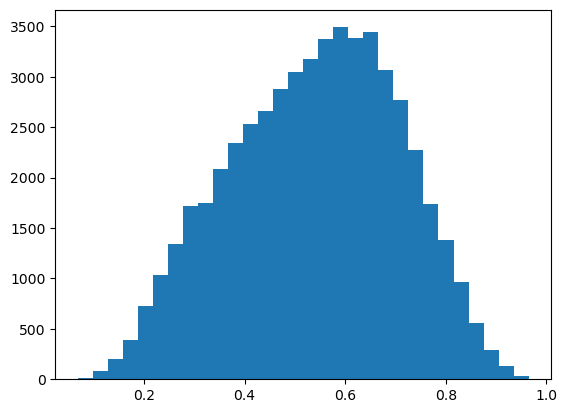

In [20]:
import matplotlib.pyplot as plt
plt.hist([b for a, b in jsd.results.items()], bins=30)

patients = list(set([a[0] for a, b in jsd.results.items()]))

jsd_ctfinal_df = pd.DataFrame(index=patients, columns=[f'JSD@CT_final@{a[1]}@{a[2]}' for a, b in jsd.results.items()])
for pat, value in jsd.results.items():
    jsd_ctfinal_df.loc[pat[0], f'JSD@CT_final@{pat[1]}@{pat[2]}'] = value
jsd_ctfinal_df

In [11]:
jsd_basects = JSD.Spatial2DDensityCorrelation(adata, 'base_celltypes', 'unique_core')
jsd_basects.computeJSDAllCellTypes()

Computing for TMA_A_A1
Computing for TMA_A_A2
Computing for TMA_A_A3
Computing for TMA_A_A4
Computing for TMA_A_A5
Computing for TMA_A_A6
Computing for TMA_A_A7
Computing for TMA_A_B2
Computing for TMA_A_B3
Computing for TMA_A_B4
Computing for TMA_A_B5
Computing for TMA_A_B6
Computing for TMA_A_B7
Computing for TMA_A_C1
Computing for TMA_A_C2
Computing for TMA_A_C3
Computing for TMA_A_C4
Computing for TMA_A_C5
Computing for TMA_A_C6
Computing for TMA_A_C7
Computing for TMA_A_D1
Computing for TMA_A_D5
Computing for TMA_A_D6
Computing for TMA_A_D7
Computing for TMA_A_E1
Computing for TMA_A_E3
Computing for TMA_A_E4
Computing for TMA_A_E5
Computing for TMA_A_E6
Computing for TMA_A_E7
Computing for TMA_A_F1
Computing for TMA_A_F3
Computing for TMA_A_F4
Computing for TMA_A_F5
Computing for TMA_A_F6
Computing for TMA_A_F7
Computing for TMA_A_G1
Computing for TMA_A_G2
Computing for TMA_A_G3
Computing for TMA_A_G4
Computing for TMA_A_G5
Computing for TMA_A_G6
Computing for TMA_A_G7
Computing f

,JSD@CT_final@B_cells@Tumour,JSD@CT_final@Tumour@B_cells,JSD@CT_final@B_cells@CD4_cells,JSD@CT_final@CD4_cells@B_cells,JSD@CT_final@B_cells@Fibroblast,JSD@CT_final@Fibroblast@B_cells,JSD@CT_final@B_cells@Vessels,JSD@CT_final@Vessels@B_cells,JSD@CT_final@B_cells@Other_Stromal_cells,JSD@CT_final@Other_Stromal_cells@B_cells,...,JSD@CT_final@B_cells@CD8_cells,JSD@CT_final@CD8_cells@B_cells,JSD@CT_final@B_cells@Macrophages,JSD@CT_final@Macrophages@B_cells,JSD@CT_final@CD4_cells@CD8_cells,JSD@CT_final@CD8_cells@CD4_cells,JSD@CT_final@CD4_cells@Macrophages,JSD@CT_final@Macrophages@CD4_cells,JSD@CT_final@CD8_cells@Macrophages,JSD@CT_final@Macrophages@CD8_cells
TMA_B_I8,0.721175,0.721175,0.254147,0.254147,0.439738,0.439738,0.548313,0.548313,0.344696,0.344696,...,0.34015,0.34015,0.525219,0.525219,0.146014,0.146014,0.389025,0.389025,0.316092,0.316092
TMA_A_J6,0.813376,0.813376,0.524928,0.524928,0.599519,0.599519,0.686676,0.686676,0.578423,0.578423,...,0.594655,0.594655,0.651028,0.651028,0.277373,0.277373,0.330508,0.330508,0.176863,0.176863
TMA_A_G6,0.706916,0.706916,0.307463,0.307463,0.500181,0.500181,0.605323,0.605323,0.454795,0.454795,...,0.398436,0.398436,0.425025,0.425025,0.195226,0.195226,0.281254,0.281254,0.228201,0.228201
TMA_A_H5,0.709206,0.709206,0.570243,0.570243,0.663468,0.663468,0.670067,0.670067,0.676726,0.676726,...,0.638165,0.638165,0.703633,0.703633,0.190389,0.190389,0.322521,0.322521,0.265593,0.265593
TMA_A_J2,0.626306,0.626306,0.493857,0.493857,0.624929,0.624929,0.539961,0.539961,0.594929,0.594929,...,0.501722,0.501722,0.522454,0.522454,0.287726,0.287726,0.287727,0.287727,0.185406,0.185406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_A_B5,0.687818,0.687818,0.638757,0.638757,0.679154,0.679154,0.578342,0.578342,0.602984,0.602984,...,0.739952,0.739952,0.693848,0.693848,0.211391,0.211391,0.215399,0.215399,0.281888,0.281888
TMA_B_J3,0.604961,0.604961,0.457484,0.457484,0.495706,0.495706,0.505103,0.505103,0.451691,0.451691,...,0.508403,0.508403,0.518134,0.518134,0.192314,0.192314,0.190355,0.190355,0.11794,0.11794
TMA_B_C3,0.769149,0.769149,0.593709,0.593709,0.740961,0.740961,0.745175,0.745175,0.745475,0.745475,...,0.672347,0.672347,0.734121,0.734121,0.233585,0.233585,0.292767,0.292767,0.289283,0.289283
TMA_B_H6,0.656539,0.656539,0.628868,0.628868,0.667875,0.667875,0.695892,0.695892,0.678632,0.678632,...,0.657906,0.657906,0.589909,0.589909,0.311954,0.311954,0.336879,0.336879,0.249513,0.249513


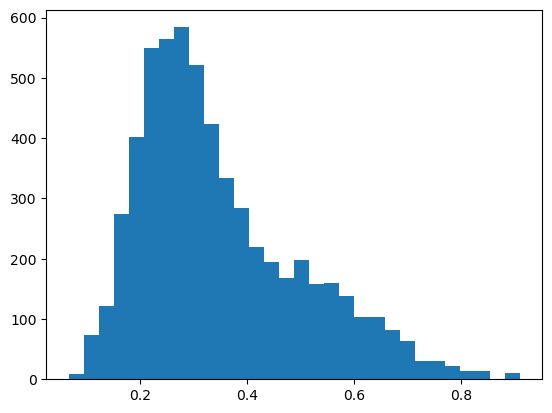

In [21]:
import matplotlib.pyplot as plt
plt.hist([b for a, b in jsd_basects.results.items()], bins=30)

patients = list(set([a[0] for a, b in jsd_basects.results.items()]))

jsd_basect_df = pd.DataFrame(index=patients, columns=[f'JSD@CT_final@{a[1]}@{a[2]}' for a, b in jsd_basects.results.items()])
for pat, value in jsd_basects.results.items():
    jsd_basect_df.loc[pat[0], f'JSD@CT_final@{pat[1]}@{pat[2]}'] = value
jsd_basect_df

In [25]:
gcrossdf1 = pd.DataFrame(data=adata.uns['CT_final_gcross_auc'], columns=['GCross:CT_final:' + a for a in adata.uns['CT_final_gcross_auc_labels']], \
                                                                         index=sorted(adata.obs['unique_core'].unique()))
gcrossdf2 = pd.DataFrame(data=adata.uns['Metabolic_baseCT_gcross_auc'], columns=['GCross:Metabolic_baseCT:' + a for a in adata.uns['Metabolic_baseCT_gcross_auc_labels']], \
                                                                                 index=sorted(adata.obs['unique_core'].unique()))
gcrossdf3 = pd.DataFrame(data=adata.uns['base_celltypes_gcross_auc'], columns=['GCross:base_celltypes:' + a for a in adata.uns['base_celltypes_gcross_auc_labels']], \
                         index=sorted(adata.obs['unique_core'].unique()))
gcrossdf = pd.concat([gcrossdf1, gcrossdf2, gcrossdf3], axis=1)

In [26]:
from spatial_analysis.utils import ObsHelper

nb_cols = ['nb_tumour_nontumour_20_3', 'nb_tumour_nontumour_50_2']
ct_cols = ['CT_basetumour', 'CT_final', 'CT_metatumour_funcimmu', 'Metabolic_allcells', 'Metabolic_baseCT_filtered', 'structural_immune_tumour_functional']

def calculatepropsinnbs(adata, nb_col, ct_col, sample_id):
    agg_helper = ObsHelper(adata, [nb_col, sample_id]) # By core + neighborhood operations
    df= agg_helper.get_metadata_df(ct_col, skey_handle="category_proportions")
    df = df.reset_index().melt(id_vars=[sample_id, nb_col],value_vars=set(adata.obs[ct_col])).pivot(index=sample_id, columns = [ct_col,nb_col], values = 'value').fillna(0)
    df = single_index(df)
    return df

def single_index(data):
    single_indexed = data.columns.map(lambda x: ":".join(x))
    data.columns = single_indexed
    return data

nbproportions = {}
for nb in nb_cols:
    for ct in ct_cols:
        nbproportions[f"{nb}:{ct}"] = calculatepropsinnbs(adata, nb, ct, sample_id ='unique_core')

In [ ]:
for key in nbproportions.keys():
    nb_temp1 = nbproportions[key]
    nb_temp1.index = nb_temp1.index.astype(str)
    val = key.split(':')[1]
    nb_temp1.columns = [f'nb:{val}' + a if a != 'unique_core' else a for a in nb_temp1.columns]

dfPatientAnnData = pd.concat([gcrossdf, jsd_basect_df, jsd_ctfinal_df, nb_temp1], axis=1)

In [32]:
dfPatientAnnData['patientID'] = dfPatientAnnData.index.map(adata.obs.groupby(by='patientID').first()[['adjtma_PCF_repA']].reset_index().set_index('adjtma_PCF_repA').to_dict()['patientID'])
dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), 'patientID'] = dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), :].index.map(adata.obs.groupby(by='patientID').first()[['adjtma_PCF_repB']].reset_index().set_index('adjtma_PCF_repB').to_dict()['patientID'])
dfPatientAnnData['Relapse_status'] = dfPatientAnnData['patientID'].map(adata.obs.groupby(by='patientID').first()[['Relapse_status']].to_dict()['Relapse_status'])
dfPatientAnnData['Relapse_followup'] = dfPatientAnnData['patientID'].map(adata.obs.groupby(by='patientID').first()[['Relapse_followup']].to_dict()['Relapse_followup'])
dfPatientAnnData['Histology'] = dfPatientAnnData['patientID'].map(adata.obs.groupby(by='patientID').first()[['Histology']].to_dict()['Histology'])

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_27678/3350725016.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfPatientAnnData['patientID'] = dfPatientAnnData.index.map(adata.obs.groupby(by='patientID').first()[['adjtma_PCF_repA']].reset_index().set_index('adjtma_PCF_repA').to_dict()['patientID'])
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_27678/3350725016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), 'patientID'] = dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), :].index.map(adata.obs.groupby(by='pat

In [148]:
dfPatientAnnData_LUAD = dfPatientAnnData[(dfPatientAnnData['Histology'] == 'Adenocarcinoma') & (dfPatientAnnData['Relapse_followup'] != '#VALUE!')]

dfPatientAnnData_LUAD = dfPatientAnnData_LUAD.loc[:,~dfPatientAnnData_LUAD.columns.duplicated()].copy()

In [149]:
dfPatientAnnData_LUAD

,GCross:CT_final:B_cells_@_to_@_B_cells,GCross:CT_final:B_cells_@_to_@_CD44+,GCross:CT_final:B_cells_@_to_@_CD44+_PDL1+,GCross:CT_final:B_cells_@_to_@_CD4_TFH,GCross:CT_final:B_cells_@_to_@_CD4_cells,GCross:CT_final:B_cells_@_to_@_CD8_cells,GCross:CT_final:B_cells_@_to_@_Cytotoxic_CD8_cells,GCross:CT_final:B_cells_@_to_@_Fibroblast,GCross:CT_final:B_cells_@_to_@_MHC_I,GCross:CT_final:B_cells_@_to_@_MHC_I&II,...,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Tumour,patientID,Relapse_status,Relapse_followup,Histology
TMA_A_A1,NaN,152.500000,NaN,NaN,442.500000,407.500000,NaN,477.500000,NaN,NaN,...,0.000000,0.000000,0.009488,0.000715,0.000000,0.000000,B43,0.0,1968,Adenocarcinoma
TMA_A_A3,410.278402,173.277356,NaN,432.380336,480.450102,422.354514,NaN,461.706622,209.722146,431.574550,...,0.000719,0.002236,0.002158,0.000172,0.000000,0.000000,B32,1.0,233,Adenocarcinoma
TMA_A_A4,454.722902,NaN,NaN,474.585187,484.338594,435.916967,344.187853,470.578351,339.541904,325.001611,...,0.000560,0.001013,0.001791,0.003040,0.000224,0.004053,B27,0.0,1204,Adenocarcinoma
TMA_A_A7,470.036680,NaN,NaN,467.037067,481.631248,470.054998,405.550093,454.357501,390.991007,356.961244,...,0.000227,0.001428,0.001591,0.001071,0.001591,0.000000,B11,1.0,371,Adenocarcinoma
TMA_A_B3,483.487255,268.948235,NaN,458.186900,477.148317,455.593010,309.207500,436.626225,168.253006,379.387752,...,0.002913,0.001144,0.014036,0.000000,0.000000,0.000000,B32,1.0,233,Adenocarcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_J2,320.762880,433.805838,112.386836,NaN,463.670546,471.529575,NaN,481.751343,182.363011,NaN,...,0.000000,0.000000,0.008187,0.001635,0.003275,0.000117,B81,1.0,2262,Adenocarcinoma
TMA_B_J3,316.387293,429.563981,355.928055,342.377513,474.452651,473.060428,351.240758,442.815450,371.086561,NaN,...,0.000000,0.000000,0.000358,0.000127,0.000000,0.000000,B76,0.0,995,Adenocarcinoma
TMA_B_J4,434.068085,186.383429,NaN,96.328520,478.179512,475.967355,NaN,479.355990,407.156550,184.682761,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,B71,1.0,214,Adenocarcinoma
TMA_B_J7,483.362621,371.936770,283.773123,395.127464,484.430148,478.152970,128.943721,461.793400,431.861489,351.551859,...,0.000000,0.000000,0.000416,0.000161,0.000000,0.000000,B56,0.0,2558,Adenocarcinoma


In [150]:
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(n_quantiles=dfPatientAnnData_LUAD.shape[0], random_state=0)

cols = dfPatientAnnData_LUAD.columns.isin([
        'patientID', 'Relapse_status', 'Relapse_followup', 'Histology'
    ])

dfPatientAnnData_LUAD.loc[:,~cols] = pd.DataFrame(qt.fit_transform(dfPatientAnnData_LUAD.loc[:,~cols]), 
                                       columns=dfPatientAnnData_LUAD.columns[~cols], 
                                       index=dfPatientAnnData_LUAD.index
)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [151]:
dfPatientAnnData_LUAD

,GCross:CT_final:B_cells_@_to_@_B_cells,GCross:CT_final:B_cells_@_to_@_CD44+,GCross:CT_final:B_cells_@_to_@_CD44+_PDL1+,GCross:CT_final:B_cells_@_to_@_CD4_TFH,GCross:CT_final:B_cells_@_to_@_CD4_cells,GCross:CT_final:B_cells_@_to_@_CD8_cells,GCross:CT_final:B_cells_@_to_@_Cytotoxic_CD8_cells,GCross:CT_final:B_cells_@_to_@_Fibroblast,GCross:CT_final:B_cells_@_to_@_MHC_I,GCross:CT_final:B_cells_@_to_@_MHC_I&II,...,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Tumour,patientID,Relapse_status,Relapse_followup,Histology
TMA_A_A1,NaN,0.030143,NaN,NaN,0.039552,0.038605,NaN,0.814103,NaN,NaN,...,0.000000,0.000000,0.846154,0.551282,0.000000,0.000000,B43,0.0,1968,Adenocarcinoma
TMA_A_A3,0.232191,0.048699,NaN,0.675866,0.604526,0.053495,NaN,0.304796,0.153513,0.790977,...,0.910256,0.910256,0.487179,0.307692,0.000000,0.000000,B32,1.0,233,Adenocarcinoma
TMA_A_A4,0.431693,NaN,NaN,0.964368,0.920684,0.067244,0.473832,0.582004,0.347253,0.311748,...,0.846154,0.871795,0.448718,0.884615,0.500000,0.987179,B27,0.0,1204,Adenocarcinoma
TMA_A_A7,0.575504,NaN,NaN,0.933391,0.689866,0.333333,0.835317,0.121574,0.488808,0.437994,...,0.756410,0.897436,0.397436,0.641026,0.756410,0.000000,B11,1.0,371,Adenocarcinoma
TMA_A_B3,0.936164,0.160922,NaN,0.842976,0.407638,0.113438,0.311689,0.013716,0.083453,0.545339,...,0.961538,0.884615,0.923077,0.000000,0.000000,0.000000,B32,1.0,233,Adenocarcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_J2,0.061179,0.885608,0.128612,NaN,0.174755,0.412267,NaN,0.947459,0.101986,NaN,...,0.000000,0.000000,0.756410,0.769231,0.923077,0.692308,B81,1.0,2262,Adenocarcinoma
TMA_B_J3,0.051030,0.809957,0.868175,0.249221,0.352663,0.539403,0.528535,0.027844,0.438954,NaN,...,0.000000,0.000000,0.089744,0.256410,0.000000,0.000000,B76,0.0,995,Adenocarcinoma
TMA_B_J4,0.311646,0.062899,NaN,0.034352,0.461655,0.640567,NaN,0.915012,0.623380,0.046933,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,B71,1.0,214,Adenocarcinoma
TMA_B_J7,0.921807,0.489692,0.574173,0.475513,0.931458,0.757518,0.102572,0.311378,0.859735,0.397233,...,0.000000,0.000000,0.102564,0.282051,0.000000,0.000000,B56,0.0,2558,Adenocarcinoma


# Feature Selection

In [134]:
class SurvivalStratifiedGroupRepeatedKFold(
    SurvivalStratifyMixin,
    StrictGroupMixin,
    RepeatedStratifiedKFold,
):
    """
    Repeated stratified K-fold that splits at the *patient* level.

    - Groups (patient IDs) are kept intact: both TMA cores of the same patient
      always end up in the same fold.
    - Stratification is by event-observed status, so the event rate is balanced
      across folds even with the group constraint.
    - Works with scikit-survival structured arrays for Y directly.

    Usage
    -----
    splitter = SurvivalStratifiedGroupRepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
    for train_idx, test_idx in splitter.split(X, Y, groups=patient_ids):
        ...
    """
    pass

In [ ]:
meta_cols = ['patientID', 'Relapse_status', 'Relapse_followup', 'Histology']

X_raw = dfPatientAnnData_LUAD.loc[:, ~dfPatientAnnData_LUAD.columns.isin(meta_cols)].copy()

Y = sksurv.util.Surv().from_dataframe(
    data=dfPatientAnnData_LUAD[['Relapse_status', 'Relapse_followup']].rename(
        columns={'Relapse_followup': 'time', 'Relapse_status': 'event'}
    ),
    time='time',
    event='event',
)

patient_groups = dfPatientAnnData_LUAD['patientID'].values

n_cores    = X_raw.shape[0]
n_patients = len(np.unique(patient_groups))
print(f"LUAD cohort: {n_cores} TMA cores from {n_patients} unique patients")
print(f"Event rate: {Y['event'].mean():.1%}")

LUAD cohort: 79 TMA cores from 44 unique patients
Event rate: 48.1%


In [142]:
X_raw

,GCross:CT_final:B_cells_@_to_@_B_cells,GCross:CT_final:B_cells_@_to_@_CD44+,GCross:CT_final:B_cells_@_to_@_CD44+_PDL1+,GCross:CT_final:B_cells_@_to_@_CD4_TFH,GCross:CT_final:B_cells_@_to_@_CD4_cells,GCross:CT_final:B_cells_@_to_@_CD8_cells,GCross:CT_final:B_cells_@_to_@_Cytotoxic_CD8_cells,GCross:CT_final:B_cells_@_to_@_Fibroblast,GCross:CT_final:B_cells_@_to_@_MHC_I,GCross:CT_final:B_cells_@_to_@_MHC_I&II,...,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PDL1_PD1_HLAA:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PDL1_PD1_HLAA:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_GRZMB:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_GRZMB:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Tumour
TMA_A_A1,NaN,0.030143,NaN,NaN,0.039552,0.038605,NaN,0.814103,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.846154,0.551282,0.000000,0.000000
TMA_A_A3,0.232191,0.048699,NaN,0.675866,0.604526,0.053495,NaN,0.304796,0.153513,0.790977,...,0.935897,0.910256,0.000000,0.000000,0.910256,0.910256,0.487179,0.307692,0.000000,0.000000
TMA_A_A4,0.431693,NaN,NaN,0.964368,0.920684,0.067244,0.473832,0.582004,0.347253,0.311748,...,0.974359,0.961538,0.397436,0.000000,0.846154,0.871795,0.448718,0.884615,0.500000,0.987179
TMA_A_A7,0.575504,NaN,NaN,0.933391,0.689866,0.333333,0.835317,0.121574,0.488808,0.437994,...,0.000000,0.000000,0.666667,0.743590,0.756410,0.897436,0.397436,0.641026,0.756410,0.000000
TMA_A_B3,0.936164,0.160922,NaN,0.842976,0.407638,0.113438,0.311689,0.013716,0.083453,0.545339,...,0.000000,0.858974,0.000000,0.000000,0.961538,0.884615,0.923077,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_J2,0.061179,0.885608,0.128612,NaN,0.174755,0.412267,NaN,0.947459,0.101986,NaN,...,0.000000,0.000000,0.884615,0.782051,0.000000,0.000000,0.756410,0.769231,0.923077,0.692308
TMA_B_J3,0.051030,0.809957,0.868175,0.249221,0.352663,0.539403,0.528535,0.027844,0.438954,NaN,...,0.000000,0.000000,0.525641,0.807692,0.000000,0.000000,0.089744,0.256410,0.000000,0.000000
TMA_B_J4,0.311646,0.062899,NaN,0.034352,0.461655,0.640567,NaN,0.915012,0.623380,0.046933,...,0.000000,0.000000,0.730769,0.871795,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
TMA_B_J7,0.921807,0.489692,0.574173,0.475513,0.931458,0.757518,0.102572,0.311378,0.859735,0.397233,...,0.000000,0.000000,0.653846,0.820513,0.000000,0.000000,0.102564,0.282051,0.000000,0.000000


In [ ]:
preprocessing = Pipeline(
    steps=[
        #("variance", VarianceThreshold(0.0)),
        ("lif",      LowInfoFilter(max_nan_fraction=0.6)),
        ("impute",   SimpleImputer(strategy="median")),
        ("std",      StandardScaler()),
    ]
)

In [153]:
preprocessing.fit_transform(X_raw)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[ 0.00181711, -1.78089585, -0.00542093, ...,  0.24041923,
        -1.06229907, -0.67454908],
       [-1.01636797, -1.71053809,  0.6779606 , ..., -0.50058542,
        -1.06229907, -0.67454908],
       [-0.25994347, -0.00501688,  1.78879998, ...,  1.2544256 ,
         0.25425099,  1.81228853],
       ...,
       [-0.715108  , -1.65669581, -1.79211359, ..., -1.43659131,
        -1.06229907, -0.67454908],
       [ 1.59834669, -0.03847531, -0.0934771 , ..., -0.57858591,
        -1.06229907, -0.67454908],
       [ 0.83770064,  1.24318331, -1.48298567, ..., -0.11058297,
        -1.06229907, -0.67454908]], shape=(79, 11645))

In [ ]:
random_state = 42

splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4,
    n_repeats=5,
    random_state=random_state,
)

n_folds = splitter.get_n_splits(X_raw, Y, groups=patient_groups)
print(f"Total CV folds: {n_folds}  (n_splits × n_repeats = 4 × 5)")

Total CV folds: 20  (n_splits × n_repeats = 4 × 2)


# Test Whole Cohort Feature Selection

In [155]:
from sklearn.impute import SimpleImputer
from stabl.preprocessing import LowInfoFilter
from sklearn.feature_selection import VarianceThreshold
 
preprocessing = Pipeline(
    steps=[
        ('variance_threshold', VarianceThreshold(threshold=0.0)),
        ('low_info_filter', LowInfoFilter(max_nan_fraction=0.1)),
        ('imputer', SimpleImputer(strategy='median')),
        ('std', StandardScaler())
    ]
)

preprocessing.fit(X_raw)
pre_X_all = pd.DataFrame(preprocessing.transform(X_raw), columns=preprocessing.get_feature_names_out(X_raw.columns), index=X_raw.index)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:122: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  

In [ ]:
from sklearn.pipeline import make_pipeline

from skglm import CoxEstimator
class CoxEstimatorWrapper(CoxEstimator):
    """
    Wraps skglm.CoxEstimator so that it accepts y as
    a structured array, and internally converts it
    to the (n_samples, 2) array [time, event] for CoxEstimator.
    """
    def fit(self, X, y, **fit_kwargs):
        event_field, time_field = y.dtype.names
        y_mat = np.column_stack((y[time_field], y[event_field]))
        return super().fit(X, y_mat, **fit_kwargs)

    def predict(self, X):
        X = np.asarray(X)  
        return super().predict(X)

cox = CoxnetFitter(tol=1e-6, max_iter=int(1e5), l1_ratio=l1_ratio)

stabl_regression = Stabl(
    base_estimator=clone(cox),
    lambda_grid={'alphas': [[al] for al in alpha_grid], },
    #n_lambda=10,
    artificial_type="knockoff",
    artificial_proportion=1,
    n_bootstraps=200,
    random_state=42,
    verbose=1,
)

stabl_regression.fit(pre_X_all, Y)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Stabl progress:   0%|          | 0/10 [00:00<?, ?it/s]

/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super(

Stabl(artificial_proportion=1, artificial_type='knockoff',
      base_estimator=CoxnetFitter(l1_ratio=0.95, tol=1e-06),
      fdr_threshold_range=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43...
      lambda_grid={'alphas': [[np.float64(0.0001)],
                              [np.float64(0.0001668100537200059)],
                              [np.float64(0.0002782559402207126)],
                              [np.float64(0.00046415888336127773)],
                              [np.float64(0.000774263682681127)],
                              [np.float64(0.001291549665014884)],
                              [np.float64(0.002154434690031882)],
                              [np.float64(0.003593813663804626)],
                              [np.float64(0.005994842503189409)],
                              [np.float64(0.01)]]},
      n_bootstraps=200, random_state=42, verbose=1)

In [ ]:
stabl_regression.fitted_lambda_grid_ = {'alpha': alpha_grid}

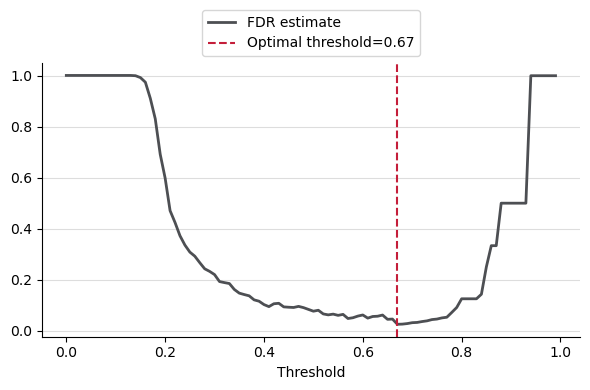

In [422]:
from stabl.stabl import Stabl, plot_stabl_path, plot_fdr_graph

plot_fdr_graph(stabl_regression, figsize=(6, 4))
plt.savefig('stabl_curve.svg')

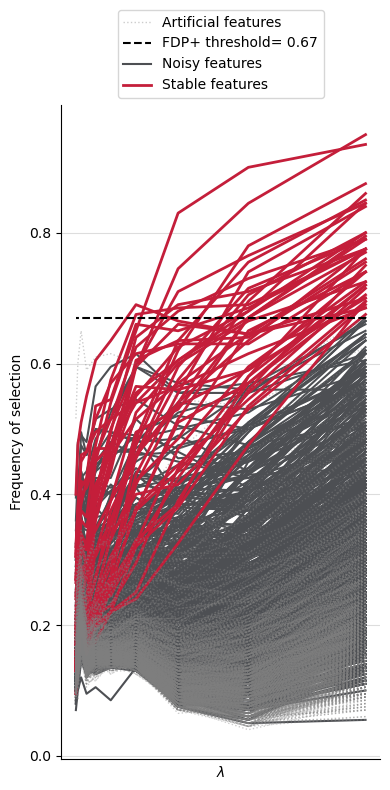

In [423]:
plot_stabl_path(stabl_regression, figsize=(4,8))
plt.savefig('paths_curve.svg')

In [160]:
stabl_regression.get_feature_names_out()

array(['GCross:CT_final:B_cells_@_to_@_CD4_cells',
       'GCross:CT_final:B_cells_@_to_@_CD8_cells',
       'GCross:CT_final:B_cells_@_to_@_Fibroblast',
       'GCross:CT_final:B_cells_@_to_@_Macrophages',
       'GCross:CT_final:B_cells_@_to_@_Other_Stromal_cells',
       'GCross:CT_final:B_cells_@_to_@_Tumour',
       'GCross:CT_final:B_cells_@_to_@_Vessels',
       'GCross:CT_final:CD44+_@_to_@_CD4_cells',
       'GCross:CT_final:CD44+_@_to_@_CD8_cells',
       'GCross:CT_final:CD44+_@_to_@_Fibroblast',
       'GCross:CT_final:CD44+_@_to_@_Macrophages',
       'GCross:CT_final:CD44+_@_to_@_Other_Stromal_cells',
       'GCross:CT_final:CD44+_@_to_@_Tumour',
       'GCross:CT_final:CD44+_@_to_@_Vessels',
       'GCross:CT_final:CD4_TFH_@_to_@_CD8_cells',
       'GCross:CT_final:CD4_TFH_@_to_@_Macrophages',
       'GCross:CT_final:CD4_cells_@_to_@_CD4_cells',
       'GCross:CT_final:CD4_cells_@_to_@_Macrophages_M2',
       'GCross:CT_final:CD4_cells_@_to_@_Other_Stromal_cells',
      

## STABL-Cox model

In [161]:
l1_ratio   = 0.95
alpha_grid = np.geomspace(1e-4, 1e-2, num=10)

cox_fitter = CoxnetFitter(tol=1e-6, max_iter=int(1e5), l1_ratio=l1_ratio)

stabl_cox = Stabl(
    base_estimator=cox_fitter,
    lambda_grid={
        "alphas":    [[al] for al in alpha_grid],
        "l1_ratio":  [l1_ratio],
    },
    n_bootstraps=200,
    artificial_type='knockoff',
    artificial_proportion=1.0,
    sample_fraction=0.5,
    fdr_threshold_range=np.arange(0.001, 1.0, 0.001),
    random_state=random_state,
    verbose=30,
    n_jobs=16,
)

## Run Feature Selection in Cross-Validation

In [ ]:
import importlib
import cox_cv_pipeline
importlib.reload(cox_cv_pipeline)
from cox_cv_pipeline import survival_stabl_cv

cv_results_corrected = survival_stabl_cv(
    x_data=X_raw,                          
    y_data=Y,
    fold_splitter=splitter,
    model=stabl_cox,
    fold_groups=patient_groups,            # patient-level grouping
    preprocessing_pipeline=preprocessing,  # fit preprocessing per fold
    save_path=None,
    override=False,
    redo_preprocessing_on_test=False,      # test fold uses train-fold statistics
    differnet_penalty_factors=False,
)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:122: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


Starting fold 1 of 20


/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Stabl progress:   0%|          | 0/10 [00:00<?, ?it/s]

/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super(

...

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:122: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  

Stabl progress:   0%|          | 0/10 [00:00<?, ?it/s]

/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super().fit(X, y)
/Users/aaronkilgallon/Documents/AdjuvantPaper/rebuttal/feature_selection_separate_histologies/cox_fits.py:101: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=100000).
  super(

Saving cross validation results


/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetFitter was fitted without feature names
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetFitter was fitted without feature names
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetFitter was fitted without feature names
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but CoxnetFitter was fitted without feature names
  warnings.warn(


In [229]:
cv_results_corrected.to_csv('correctedCVPipeline.csv')
cv_results_corrected

,selected_features,fdr_est,fdp_threshold,best_parameters,train_concordance,test_concordance,train_indices,test_indices
0,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.017391,0.415,"{'alphas': [0.0001], 'l1_ratio': 0.95}",1.000000,0.731250,"[12, 16, 19, 22, 28, 32, 37, 41, 27, 31, 36, 4...","[3, 6, 11, 15, 35, 39, 2, 5, 17, 20, 34, 7, 13..."
1,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.034483,0.635,"{'alphas': [0.0001668100537200059], 'l1_ratio'...",0.974293,0.295082,"[3, 6, 12, 16, 19, 22, 28, 32, 37, 41, 11, 15,...","[27, 31, 36, 40, 18, 21, 26, 30, 25, 24, 73, 7..."
2,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.037037,0.650,"{'alphas': [0.000774263682681127], 'l1_ratio':...",0.903358,0.443396,"[3, 6, 12, 16, 28, 32, 37, 41, 11, 15, 27, 31,...","[19, 22, 9, 1, 4, 33, 38, 0, 44, 47, 50, 54, 7..."
3,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.015625,0.510,"{'alphas': [0.0001], 'l1_ratio': 0.95}",1.000000,0.390909,"[3, 6, 19, 22, 11, 15, 27, 31, 36, 40, 18, 21,...","[12, 16, 28, 32, 37, 41, 10, 14, 8, 23, 29, 51..."
4,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.016667,0.535,"{'alphas': [0.002154434690031882], 'l1_ratio':...",1.000000,0.424779,"[3, 6, 12, 16, 27, 31, 36, 40, 10, 14, 18, 21,...","[19, 22, 28, 32, 37, 41, 11, 15, 25, 8, 23, 29..."
5,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.027778,0.550,"{'alphas': [0.00046415888336127773], 'l1_ratio...",0.988149,0.533333,"[3, 6, 19, 22, 28, 32, 37, 41, 11, 15, 27, 31,...","[12, 16, 36, 40, 35, 39, 2, 5, 24, 33, 38, 7, ..."
6,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.043478,0.665,"{'alphas': [0.000774263682681127], 'l1_ratio':...",0.847118,0.601852,"[3, 6, 12, 16, 19, 22, 28, 32, 37, 41, 11, 15,...","[27, 31, 10, 14, 18, 21, 17, 20, 34, 51, 55, 5..."
7,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.025000,0.605,"{'alphas': [0.01], 'l1_ratio': 0.95}",0.962264,0.278689,"[12, 16, 19, 22, 28, 32, 37, 41, 11, 15, 27, 3...","[3, 6, 26, 30, 9, 1, 4, 0, 59, 63, 66, 69, 72,..."
8,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.047619,0.660,"{'alphas': [0.005994842503189409], 'l1_ratio':...",0.930112,0.256198,"[37, 41, 27, 31, 36, 40, 10, 14, 18, 21, 26, 3...","[3, 6, 12, 16, 19, 22, 28, 32, 11, 15, 24, 8, ..."
9,"[GCross:CT_final:B_cells_@_to_@_CD4_cells, GCr...",0.019608,0.560,"{'alphas': [0.0001], 'l1_ratio': 0.95}",0.500000,0.500000,"[3, 6, 12, 16, 19, 22, 28, 32, 37, 41, 11, 15,...","[27, 31, 2, 5, 9, 25, 23, 29, 73, 78, 43, 46, ..."


## Summary statistics

In [ ]:
print("=== Concordance across all folds ===")
print(cv_results_corrected[['train_concordance', 'test_concordance']].describe().round(3))

from collections import Counter

feature_counts = Counter(
    f
    for features in cv_results_corrected['selected_features']
    for f in features
)

stability_df = (
    pd.DataFrame.from_dict(feature_counts, orient='index', columns=['fold_count'])
    .assign(stability=lambda d: d['fold_count'] / len(cv_results_corrected))
    .sort_values('stability', ascending=False)
)

print(f"\n=== Feature selection stability (across {len(cv_results_corrected)} folds) ===")
print(stability_df[stability_df['fold_count'] > 1])

=== Concordance across all folds ===
       train_concordance  test_concordance
count             20.000            20.000
mean               0.936             0.458
std                0.113             0.132
min                0.500             0.256
25%                0.928             0.366
50%                0.968             0.434
75%                1.000             0.553
max                1.000             0.731

=== Feature selection stability (across 20 folds) ===
                                                    fold_count  stability
GCross:CT_final:B_cells_@_to_@_CD4_cells                    20        1.0
GCross:CT_final:B_cells_@_to_@_Fibroblast                   20        1.0
GCross:CT_final:B_cells_@_to_@_Macrophages                  20        1.0
GCross:CT_final:B_cells_@_to_@_Other_Stromal_cells          20        1.0
GCross:CT_final:B_cells_@_to_@_Tumour                       20        1.0
...                                                        ...        ...
nb:

In [ ]:
all_clean = True
for i, row in cv_results_corrected.iterrows():
    train_patients = set(patient_groups[row['train_indices']])
    test_patients  = set(patient_groups[row['test_indices']])
    overlap = train_patients & test_patients
    if overlap:
        print(f"Fold {i}: WARNING — patient overlap detected: {overlap}")
        all_clean = False
if all_clean:
    print("All folds clean: no patient appears in both train and test sets.")

All folds clean: no patient appears in both train and test sets.


## Final model evaluation 

In [ ]:
from thresholded_cox import ThresholdedCoxPH, PerFeatureThresholder, NaNAwareStandardScaler
from scipy import stats
from sksurv.linear_model import CoxPHSurvivalAnalysis

from sklearn.model_selection import ParameterGrid
from sksurv.metrics import concordance_index_censored
from sksurv.ensemble import RandomSurvivalForest

from sklearn.model_selection import ParameterGrid
from sksurv.metrics import concordance_index_censored

from sksurv.ensemble import GradientBoostingSurvivalAnalysis


### Select top features by CV stability


In [371]:
N_TOP_FEATURES = 40

top_features = stability_df.head(N_TOP_FEATURES).index.tolist()
X_top = X_raw[top_features]

missing = [f for f in top_features if f not in X_raw.columns]
if missing:
    print(f"WARNING: {len(missing)} features not found in X_raw and will be dropped: {missing}")
    top_features = [f for f in top_features if f not in missing]

print(f"Using {len(top_features)} features for the final models:\n")
print(stability_df.loc[top_features].to_string())

Using 40 features for the final models:

                                                                                                                        fold_count  stability
GCross:CT_final:B_cells_@_to_@_CD4_cells                                                                                        20       1.00
GCross:CT_final:B_cells_@_to_@_Fibroblast                                                                                       20       1.00
GCross:CT_final:B_cells_@_to_@_Macrophages                                                                                      20       1.00
GCross:CT_final:B_cells_@_to_@_Other_Stromal_cells                                                                              20       1.00
GCross:CT_final:B_cells_@_to_@_Tumour                                                                                           20       1.00
GCross:CT_final:B_cells_@_to_@_Vessels                                                                     

In [372]:
top_features

['GCross:CT_final:B_cells_@_to_@_CD4_cells',
 'GCross:CT_final:B_cells_@_to_@_Fibroblast',
 'GCross:CT_final:B_cells_@_to_@_Macrophages',
 'GCross:CT_final:B_cells_@_to_@_Other_Stromal_cells',
 'GCross:CT_final:B_cells_@_to_@_Tumour',
 'GCross:CT_final:B_cells_@_to_@_Vessels',
 'GCross:CT_final:CD44+_@_to_@_CD8_cells',
 'GCross:CT_final:B_cells_@_to_@_CD8_cells',
 'GCross:CT_final:CD44+_@_to_@_Other_Stromal_cells',
 'GCross:CT_final:CD44+_@_to_@_CD4_cells',
 'GCross:CT_final:CD44+_@_to_@_Tumour',
 'GCross:CT_final:CD4_cells_@_to_@_Other_Stromal_cells',
 'GCross:CT_final:CD4_cells_@_to_@_CD4_cells',
 'GCross:CT_final:CD4_TFH_@_to_@_CD8_cells',
 'GCross:CT_final:CD8_cells_@_to_@_Fibroblast',
 'GCross:CT_final:CD8_cells_@_to_@_CD8_cells',
 'GCross:CT_final:Tumour_@_to_@_CD4_cells',
 'nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PDL1_PD1_HLAA_ICOS_GRZMB:Tumour',
 'GCross:CT_final:CD44+_@_to_@_Fibroblast',
 'GCross:CT_final:CD8_cells_@_to_@_CD4_cell

### Cross-validation evaluation


In [ ]:
# Parameter optimisation of Random Survival Forest Model via grid search

param_grid = ParameterGrid({
    "n_estimators"    : [100, 300, 500, 1000],
    "min_samples_leaf": [1, 3, 5, 10],     
    "max_features"    : ["sqrt", "log2", 0.5],  
    "max_samples"     : [0.5, 0.7, None],
})

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=10, random_state=random_state
)


best_c, best_params = 0, None
for train_idx, test_idx in final_splitter.split(X_raw, Y, groups=patient_groups):
    X_tr_raw  = X_top.iloc[train_idx]
    X_te_raw  = X_top.iloc[test_idx]
    X_tr_full = X_raw.iloc[train_idx]  
    Y_tr      = Y[train_idx]
    Y_te      = Y[test_idx]
    for params in param_grid:
        scale = StandardScaler().fit(X_tr_raw)
        X_tr_raw = pd.DataFrame(scale.transform(X_tr_raw), index=X_tr_raw.index, columns=X_tr_raw.columns)
        X_te_raw = pd.DataFrame(scale.transform(X_te_raw), index=X_te_raw.index, columns=X_te_raw.columns)

        m = RandomSurvivalForest(n_jobs=-1,
                                 random_state=random_state,
                                 **params)
        m.fit(X_tr_raw, Y_tr)
        c = concordance_index_censored(
                Y_te["event"], Y_te["time"], m.predict(X_te_raw)
            )[0]
        if c > best_c:
            best_c, best_params = c, params

print(f"Best test C: {best_c:.4f}", best_params)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Best test C: 0.8727 {'max_features': 'sqrt', 'max_samples': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500}


In [ ]:
# Paramter optimisation via Gradient Boosting Survival modelling

param_grid = ParameterGrid({
    "learning_rate": [0.01, 0.1, 1.0],
    "n_estimators": [100, 500, 1000],
    "subsample": [0.5, 1.0],
})

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=2, random_state=random_state
)
X_here = pd.DataFrame(preprocessing.fit_transform(X_top), index=X_top.index, columns=preprocessing.get_feature_names_out())

splits = list(final_splitter.split(X_here, Y, groups=patient_groups))

best_c, best_params_gb = 0, None
for params in param_grid:
    fold_cs = []
    for train_idx, test_idx in splits:
        X_tr_raw  = X_here.iloc[train_idx]
        X_te_raw  = X_here.iloc[test_idx]
        Y_tr      = Y[train_idx]
        Y_te      = Y[test_idx]

        scale = StandardScaler().fit(X_tr_raw)
        X_tr_sc = pd.DataFrame(scale.transform(X_tr_raw), index=X_tr_raw.index, columns=X_tr_raw.columns)
        X_te_sc = pd.DataFrame(scale.transform(X_te_raw), index=X_te_raw.index, columns=X_te_raw.columns)

        m = sksurv.ensemble.ComponentwiseGradientBoostingSurvivalAnalysis(
            random_state=random_state, **params
        )
        m.fit(X_tr_sc, Y_tr)
        c = concordance_index_censored(
                Y_te["event"], Y_te["time"], m.predict(X_te_sc)
            )[0]
        fold_cs.append(c)
    mean_c = float(np.mean(fold_cs))
    if mean_c > best_c:
        best_c, best_params_gb = mean_c, params

print(f"Best CV mean C: {best_c:.4f}", best_params_gb)


/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgal

Best CV mean C: 0.6218 {'learning_rate': 1.0, 'n_estimators': 500, 'subsample': 1.0}


In [ ]:
thresh_fold_c   = []
standard_fold_c = []
gbsa_fold_c     = []

oof_thresh_risk   = np.zeros(len(X_raw))
oof_standard_risk = np.zeros(len(X_raw))
oof_gbsa_risk     = np.zeros(len(X_raw))
oof_counts        = np.zeros(len(X_raw), dtype=int)

# Store GBSA importances
gbsa_fold_importances = []

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=5, random_state=random_state
)

for train_idx, test_idx in final_splitter.split(X_raw, Y, groups=patient_groups):
    X_tr_raw  = X_top.iloc[train_idx]
    X_te_raw  = X_top.iloc[test_idx]
    X_tr_full = X_raw.iloc[train_idx]   
    Y_tr      = Y[train_idx]
    Y_te      = Y[test_idx]

    # Standard CoxPH 
    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(imputer.fit_transform(X_tr_raw))
    X_te_sc = scaler.transform(imputer.transform(X_te_raw))

    # RSF
    m = RandomSurvivalForest(n_jobs=-1,
                                 random_state=random_state,
                                 **best_params)
    m.fit(X_tr_sc, Y_tr)
    oof_thresh_risk[test_idx] += m.predict(X_te_sc)
    thresh_fold_c.append(m.score(X_te_sc, Y_te))

    try:
        cox_model = CoxPHSurvivalAnalysis(alpha=0.0001, ties="efron", n_iter=100000, tol=1e-7)
        cox_model.fit(X_tr_sc, Y_tr)
    except:
        continue

    standard_fold_c.append(cox_model.score(X_te_sc, Y_te))
    oof_standard_risk[test_idx] += cox_model.predict(X_te_sc)


    gbsa_model = sksurv.ensemble.ComponentwiseGradientBoostingSurvivalAnalysis(
        random_state=random_state, **best_params_gb
    )
    gbsa_model.fit(X_tr_sc, Y_tr)
    gbsa_fold_c.append(gbsa_model.score(X_te_sc, Y_te))
    oof_gbsa_risk[test_idx] += gbsa_model.predict(X_te_sc)
    gbsa_fold_importances.append(gbsa_model.feature_importances_[1:])

    oof_counts[test_idx] += 1

# Average OOF predictions over repeats
oof_thresh_risk   /= oof_counts
oof_standard_risk /= oof_counts
oof_gbsa_risk     /= oof_counts

thresh_fold_c   = np.array(thresh_fold_c)
standard_fold_c = np.array(standard_fold_c)
gbsa_fold_c     = np.array(gbsa_fold_c)

# Mean GBSA feature importances across all CV folds
gbsa_mean_importances = np.nanmean(gbsa_fold_importances, axis=0)

print(f"CV folds completed       : {len(thresh_fold_c)}")
print(f"OOF counts (min / max)   : {oof_counts.min()} / {oof_counts.max()}  (expected {3})")


/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


CV folds completed       : 20
OOF counts (min / max)   : 5 / 5  (expected 3)


### Concordance index with 95 % CI

A t-distribution CI is computed from the 15 fold-level test concordances.
This reflects variance across folds (both random splitting and cohort size).

In [ ]:
def concordance_ci(fold_scores, confidence=0.95):
    n  = len(fold_scores)
    m  = np.mean(fold_scores)
    se = stats.sem(fold_scores)
    lo, hi = stats.t.interval(confidence, df=n - 1, loc=m, scale=se)
    return m, lo, hi

thresh_mean,   thresh_lo,   thresh_hi   = concordance_ci(thresh_fold_c)
standard_mean, standard_lo, standard_hi = concordance_ci(standard_fold_c)
gbsa_mean,     gbsa_lo,     gbsa_hi     = concordance_ci(gbsa_fold_c)

print("=== Final model concordance — 5×3 repeated CV, 95 % CI ===")
print(f"  RSF           : {thresh_mean:.3f}  [{thresh_lo:.3f}, {thresh_hi:.3f}]")
print(f"  Standard CoxPH             : {standard_mean:.3f}  [{standard_lo:.3f}, {standard_hi:.3f}]")
print(f"  GradientBoostingSurvival   : {gbsa_mean:.3f}  [{gbsa_lo:.3f}, {gbsa_hi:.3f}]")
print()
print(f"  ThresholdedCoxPH fold scores : {np.round(thresh_fold_c, 3)}")
print(f"  Standard CoxPH   fold scores : {np.round(standard_fold_c, 3)}")
print(f"  GBSA             fold scores : {np.round(gbsa_fold_c, 3)}")


=== Final model concordance — 5×3 repeated CV, 95 % CI ===
  ThresholdedCoxPH           : 0.599  [0.548, 0.650]
  Standard CoxPH             : 0.588  [0.536, 0.640]
  GradientBoostingSurvival   : 0.646  [0.594, 0.698]

  ThresholdedCoxPH fold scores : [0.475 0.467 0.585 0.782 0.655 0.547 0.546 0.664 0.736 0.361 0.721 0.475
 0.701 0.533 0.714 0.566 0.674 0.638 0.602 0.543]
  Standard CoxPH   fold scores : [0.544 0.525 0.5   0.627 0.434 0.64  0.685 0.623 0.579 0.407 0.706 0.557
 0.5   0.6   0.6   0.876 0.62  0.571 0.442 0.729]
  GBSA             fold scores : [0.525 0.467 0.509 0.782 0.54  0.707 0.907 0.549 0.595 0.787 0.632 0.713
 0.59  0.705 0.686 0.699 0.628 0.648 0.531 0.714]


### GBSA feature importances vs. STABL stability


In [405]:
importance_df = pd.DataFrame({
    "gbsa_importance": gbsa_mean_importances,
    "stabl_stability": stability_df.loc[top_features, "stability"].values,
}, index=top_features).sort_values("gbsa_importance", ascending=False)

rank_corr, rank_p = stats.spearmanr(
    importance_df["gbsa_importance"], importance_df["stabl_stability"]
)
print("GBSA importance vs. STABL stability")
print(f"  Spearman r = {rank_corr:.3f}  (p = {rank_p:.3f})")
print()
print(importance_df.round(4).to_string())


GBSA importance vs. STABL stability
  Spearman r = -0.007  (p = 0.968)

                                                                                                                        gbsa_importance  stabl_stability
GCross:CT_final:CD8_cells_@_to_@_Fibroblast                                                                                    217.3846             0.60
GCross:CT_final:B_cells_@_to_@_CD8_cells                                                                                       196.3571             1.00
GCross:CT_final:CD44+_@_to_@_Macrophages_M2                                                                                    191.1000             0.45
GCross:CT_final:CD4_cells_@_to_@_CD8_cells                                                                                     183.4615             0.40
GCross:CT_final:CD4_cells_@_to_@_CD44+                                                                                         176.1667             0.40
GCross:CT_

### Visualisation — CI comparison and ThresholdedCoxPH coefficients

The left panel shows the per-fold concordance distribution with the
mean and 95 % CI (I-bar) for both models.

The right panel shows the ThresholdedCoxPH Cox coefficients from the full-data fit

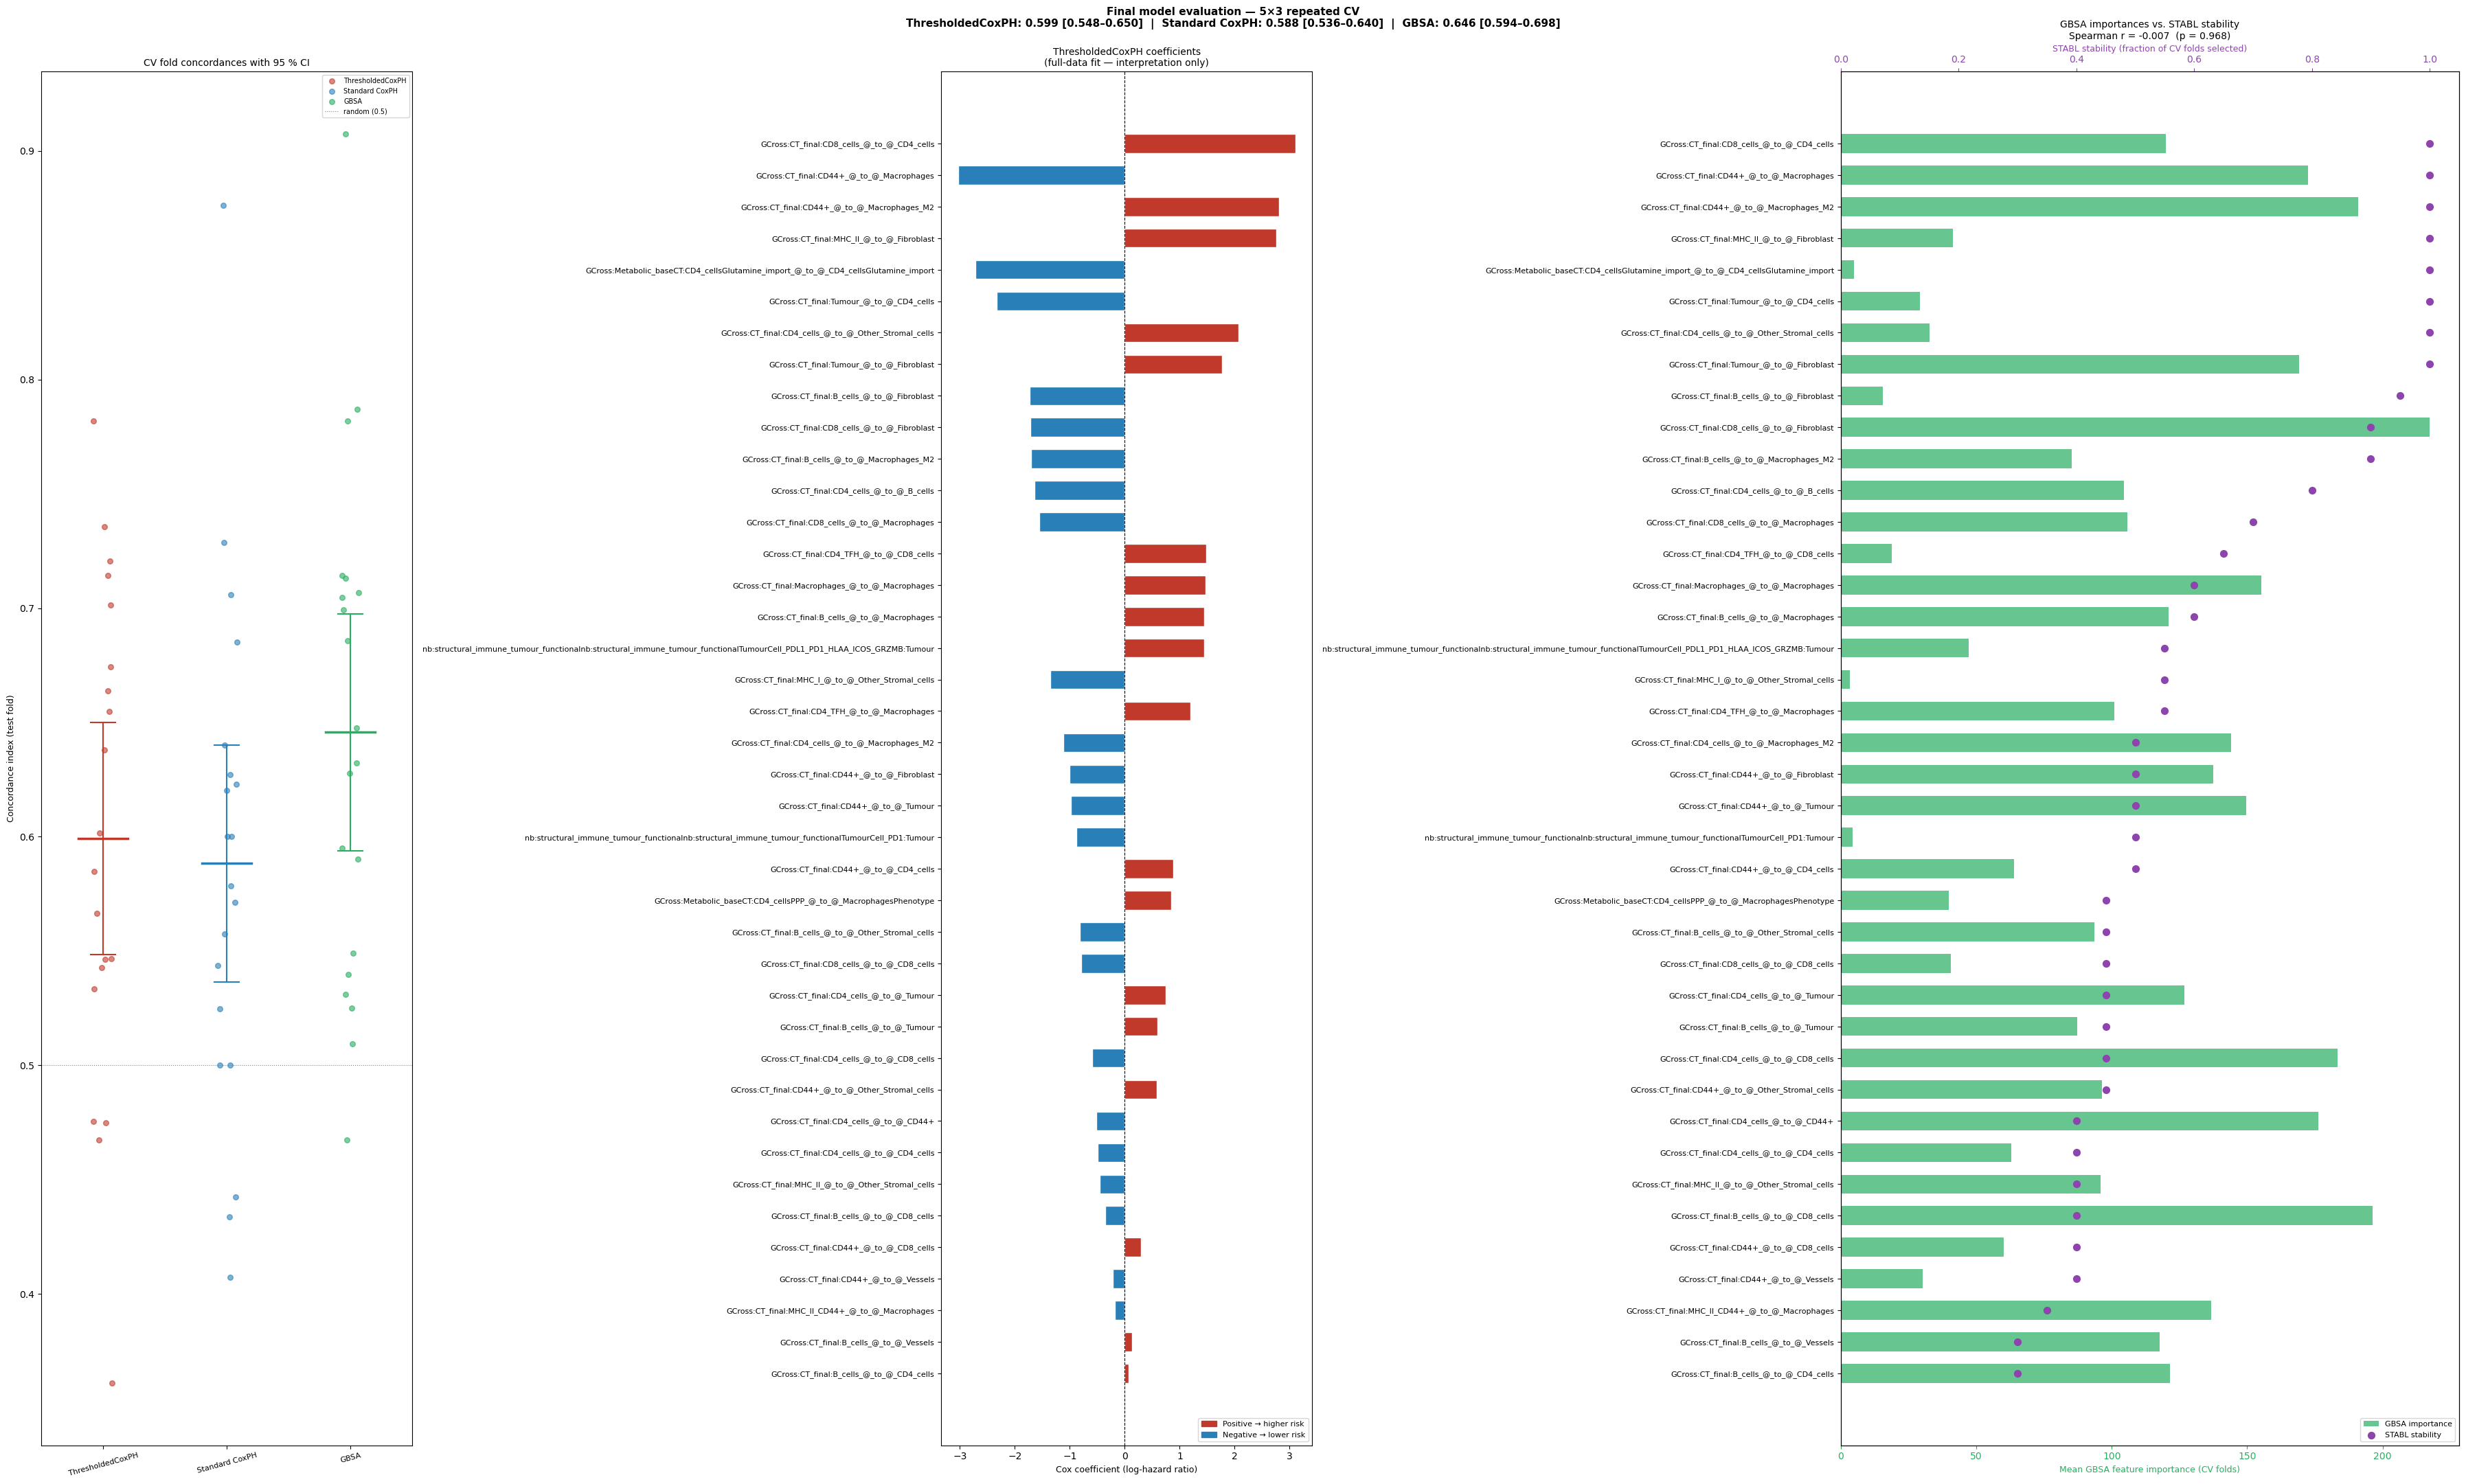

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def _short_label(name, max_chars=42):
    return name if len(name) <= max_chars else name[:max_chars - 1] + "\u2026"

sumdf  = model_all.summary()
labels = [f for f in sumdf.index]#_short_label
n      = len(labels)
ypos   = np.arange(n)
pos_col, neg_col, gbsa_col = "#c0392b", "#2980b9", "#27ae60"
coef_colors = [pos_col if c >= 0 else neg_col for c in sumdf["cox_coef"]]

fig, axes = plt.subplots(1, 3, figsize=(36, max(4, 0.55 * n)),
                         gridspec_kw={"width_ratios": [1.2, 1.2, 2]})
fig.suptitle(
    "Final model evaluation — 5\u00d73 repeated CV\n"
    f"ThresholdedCoxPH: {thresh_mean:.3f} [{thresh_lo:.3f}\u2013{thresh_hi:.3f}]  |  "
    f"Standard CoxPH: {standard_mean:.3f} [{standard_lo:.3f}\u2013{standard_hi:.3f}]  |  "
    f"GBSA: {gbsa_mean:.3f} [{gbsa_lo:.3f}\u2013{gbsa_hi:.3f}]",
    fontsize=11, fontweight="bold",
)

ax0 = axes[0]
rng = np.random.default_rng(0)
jitter = 0.08
model_specs = [
    (1, thresh_fold_c,   thresh_mean,   thresh_lo,   thresh_hi,   pos_col,  "ThresholdedCoxPH"),
    (2, standard_fold_c, standard_mean, standard_lo, standard_hi, neg_col,  "Standard CoxPH"),
    (3, gbsa_fold_c,     gbsa_mean,     gbsa_lo,     gbsa_hi,     gbsa_col, "GBSA"),
]
for x_pos, fold_scores, mean, lo, hi, col, lbl in model_specs:
    ax0.scatter(
        x_pos + rng.uniform(-jitter, jitter, len(fold_scores)),
        fold_scores, color=col, alpha=0.6, s=30, zorder=3, label=lbl,
    )
    ax0.plot([x_pos - 0.2, x_pos + 0.2], [mean, mean], color=col, linewidth=2.5, zorder=4)
    ax0.plot([x_pos, x_pos], [lo, hi], color=col, linewidth=1.5, zorder=4)
    for y_cap in (lo, hi):
        ax0.plot([x_pos - 0.1, x_pos + 0.1], [y_cap, y_cap], color=col, linewidth=1.5, zorder=4)

ax0.axhline(0.5, color="grey", linewidth=0.8, linestyle=":", label="random (0.5)")
ax0.set_xticks([1, 2, 3])
ax0.set_xticklabels(["RSF", "Standard CoxPH", "GBSA"], fontsize=8, rotation=15)
ax0.set_ylabel("Concordance index (test fold)", fontsize=9)
ax0.set_title("CV fold concordances with 95 % CI", fontsize=10)
ax0.set_xlim(0.5, 3.5)
ax0.legend(fontsize=7)

#  RSF coefficients 
ax1 = axes[1]
ax1.barh(ypos, sumdf["cox_coef"], color=coef_colors, edgecolor="white", height=0.6)
ax1.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_yticks(ypos)
ax1.set_yticklabels(labels, fontsize=8)
ax1.invert_yaxis()
ax1.set_xlabel("Cox coefficient (log-hazard ratio)", fontsize=9)
ax1.set_title("RSF coefficients\n(full-data fit — interpretation only)", fontsize=10)
ax1.legend(
    handles=[
        mpatches.Patch(color=pos_col, label="Positive \u2192 higher risk"),
        mpatches.Patch(color=neg_col, label="Negative \u2192 lower risk"),
    ],
    fontsize=8, loc="lower right",
)

ax2 = axes[2]
imp_order  = sumdf["cox_coef"].index#np.argsort(sumdf["cox_coef"].values)[::-1]
feat_labels = sumdf["cox_coef"].index#[_short_label(top_features[i]) for i in imp_order]
stab_vals  = stability_df.loc[top_features, "stability"].values#[imp_order]
imp_vals   = importance_df.loc[feat_labels,'gbsa_importance']
ypos2      = np.arange(len(imp_order))

ax2b = ax2.twiny()
ax2.barh(ypos2, imp_vals, color=gbsa_col, alpha=0.7, height=0.6, label="GBSA importance")
ax2b.scatter(stab_vals, ypos2, color="#8e44ad", zorder=5, s=50, label="STABL stability")
ax2b.set_xlim(0, 1.05)
ax2b.set_xlabel("STABL stability (fraction of CV folds selected)", fontsize=9, color="#8e44ad")
ax2b.tick_params(axis="x", colors="#8e44ad")
ax2.set_yticks(ypos2)
ax2.set_yticklabels(feat_labels, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel("Mean GBSA feature importance (CV folds)", fontsize=9, color=gbsa_col)
ax2.tick_params(axis="x", colors=gbsa_col)
ax2.set_title(
    f"GBSA importances vs. STABL stability\n"
    f"Spearman r = {rank_corr:.3f}  (p = {rank_p:.3f})",
    fontsize=10,
)
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig('CIs_GBSA_StabilityScores.svg')
plt.show()


### Kaplan-Meier stratification by out-of-fold risk score

TypeError: unsupported format string passed to numpy.ndarray.__format__

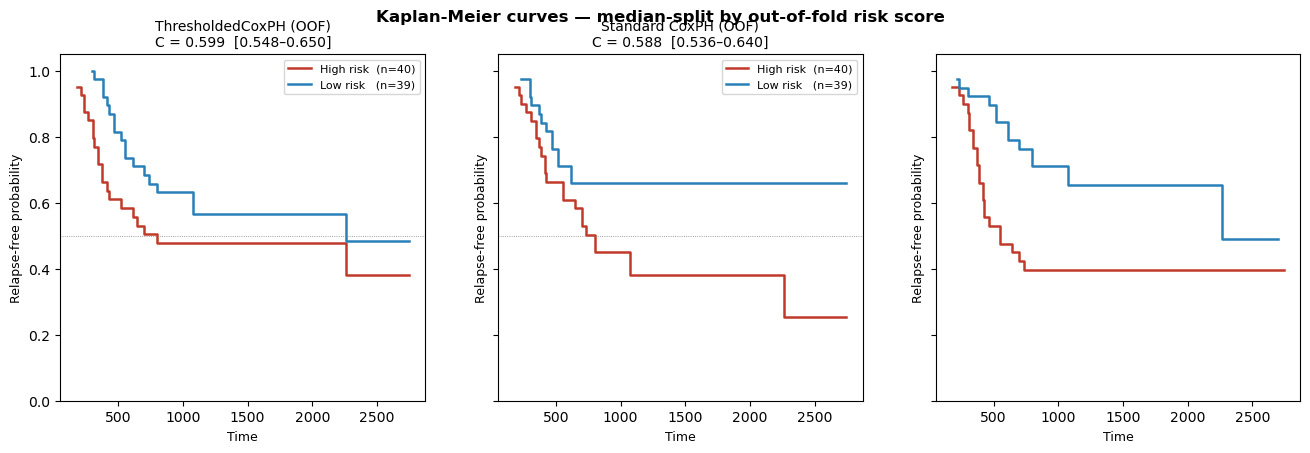

In [421]:
from sksurv.nonparametric import kaplan_meier_estimator

def plot_km_by_risk(ax, risk_scores, Y_surv, title, c_mean, c_lo, c_hi):
    """Plot KM curves split at median OOF risk score."""
    median_risk = np.median(risk_scores)
    high_mask = risk_scores >= median_risk
    low_mask  = ~high_mask

    event_field = next(f for f in Y_surv.dtype.names if "event" in f.lower())
    time_field  = next(f for f in Y_surv.dtype.names if "time"  in f.lower())

    for mask, label, color in [
        (high_mask, f"High risk  (n={high_mask.sum()})", "#c0392b"),
        (low_mask,  f"Low risk   (n={low_mask.sum()})",  "#2980b9"),
    ]:
        if mask.sum() < 2:
            continue
        t, s = kaplan_meier_estimator(
            Y_surv[event_field][mask], Y_surv[time_field][mask]
        )
        ax.step(t, s, where="post", color=color, linewidth=1.8, label=label)

    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Relapse-free probability", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f"{title}\nC = {c_mean:.3f}  [{c_lo:.3f}\u2013{c_hi:.3f}]", fontsize=10
    )
    ax.legend(fontsize=8)
    ax.axhline(0.5, color="grey", linewidth=0.6, linestyle=":")


fig, (ax_thresh, ax_std, ax_gbsa) = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
fig.suptitle(
    "Kaplan-Meier curves \u2014 median-split by out-of-fold risk score",
    fontsize=12, fontweight="bold",
)

plot_km_by_risk(
    ax_thresh, oof_thresh_risk, Y,
    title="ThresholdedCoxPH (OOF)",
    c_mean=thresh_mean, c_lo=thresh_lo, c_hi=thresh_hi,
)
plot_km_by_risk(
    ax_std, oof_standard_risk, Y,
    title="Standard CoxPH (OOF)",
    c_mean=standard_mean, c_lo=standard_lo, c_hi=standard_hi,
)
plot_km_by_risk(
    ax_gbsa, oof_gbsa_risk, Y,
    title="GBSA (OOF)",
    c_mean=gbsa_mean, c_lo=gbsa_lo, c_hi=gbsa_hi,
)

plt.tight_layout()
plt.savefig('oof.svg')
plt.show()


# KM Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test


def _parse_survival(survival):
    if isinstance(survival, (tuple, list)) and len(survival) == 2:
        d, e = survival
    elif hasattr(survival, "dtype") and survival.dtype.names:
        names = survival.dtype.names
        ev = next((n for n in names if n.lower() in ("event", "status", "cens")), names[0])
        tm = next((n for n in names if n.lower() in ("time", "duration", "t", "tte")), names[1])
        d, e = survival[tm], survival[ev]
    else:
        raise ValueError("survival must be (durations, events) or a structured array")
    return np.asarray(d, dtype=float), np.asarray(e).astype(int)


def km_by_percentile(
    df,
    survival,
    columns,
    percentiles=50,
    ncols=3,
    figsize_per_plot=(4.2, 3.5),
    show_ci=True,
):

    durations, events = _parse_survival(survival)
    if len(durations) != len(df):
        raise ValueError("survival length does not match df")

    pcts = sorted([percentiles] if np.isscalar(percentiles) else list(percentiles))
    if any(p <= 0 or p >= 100 for p in pcts):
        raise ValueError("percentiles must be strictly between 0 and 100")

    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )
    axes = axes.ravel()
    results = {}

    for i, col in enumerate(columns):
        ax = axes[i]
        x = df[col].to_numpy()
        mask = ~(pd.isna(x) | pd.isna(durations) | pd.isna(events))
        xv, dv, ev = x[mask], durations[mask], events[mask]

        if len(xv) < 2:
            ax.set_title(f"{col} (insufficient data)"); ax.axis("off"); continue

        cutoffs = np.percentile(xv, pcts)
        groups = np.digitize(xv, cutoffs, right=False)

        if len(pcts) == 1:
            labels = [f"≤ p{pcts[0]:g} ({cutoffs[0]:.3g})", f"> p{pcts[0]:g}"]
        else:
            edges = ["-∞"] + [f"{c:.3g}" for c in cutoffs] + ["+∞"]
            labels = [f"({edges[j]}, {edges[j+1]}]" for j in range(len(edges) - 1)]

        fitters, sizes = [], {}
        for g in np.unique(groups):
            sel = groups == g
            if sel.sum() < 2:
                continue
            label = f"{labels[g]}  n={sel.sum()}, ev={int(ev[sel].sum())}"
            kmf = KaplanMeierFitter(label=label).fit(dv[sel], ev[sel])
            kmf.plot_survival_function(ax=ax, ci_show=show_ci)
            fitters.append(kmf)
            sizes[labels[g]] = int(sel.sum())

        if len(np.unique(groups)) == 2:
            g0, g1 = np.unique(groups)
            test = logrank_test(dv[groups == g0], dv[groups == g1],
                                ev[groups == g0], ev[groups == g1])
        elif len(np.unique(groups)) > 2:
            test = multivariate_logrank_test(dv, groups, ev)
        else:
            test = None

        p = test.p_value if test is not None else np.nan
        stat = test.test_statistic if test is not None else np.nan

        results[col] = {
            "p_value": p, "test_statistic": stat,
            "cutoffs": cutoffs.tolist(), "group_sizes": sizes, "fitters": fitters,
        }
                
        ax.set_title(f"{col}   log-rank p = {p:.3g}")
        ax.set_xlabel("Time"); ax.set_ylabel("Survival probability")
        ax.set_ylim(0, 1.02); ax.legend(fontsize=8, loc="best")


    for j in range(len(columns), len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    plt.savefig('kms_selected.svg')


    return results, fig

In [393]:
adata

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos', 'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos', 'FOXP3_pos', 'Ki67_pos', 'Granzyme_B_pos', 'G6PD_pos', 'pNRF2_pos', 

# CoxPH Fitting

In [ ]:
for feat in top_features:
    vals = X_raw[[feat]]
    clin = pd.concat([dfPatientAnnData_LUAD[['Relapse_status', 'Relapse_followup', 'patientID']], stages2.to_frame('stage2'), stages3.to_frame('stage3'), sex.to_frame('sex')], axis=1).groupby(by='patientID').first()
    scaler = StandardScaler()
    imputer = SimpleImputer(strategy='median')
    vals = pd.DataFrame(imputer.fit_transform(vals), index=vals.index, columns=imputer.get_feature_names_out())
    vals = pd.DataFrame(scaler .fit_transform(vals), index=vals.index, columns=scaler .get_feature_names_out())
    vals = pd.concat([vals, dfPatientAnnData_LUAD[['patientID']]], axis=1).groupby(by='patientID').mean()
    vals = pd.concat([vals, clin], axis=1)
    vals['Relapse_followup'] = vals['Relapse_followup'].astype(float)

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_27678/1952484694.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stages = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['stage_grouped']
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_27678/1952484694.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sex = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['Sex']


           GCross:CT_final:B_cells_@_to_@_CD4_cells  Relapse_status  \
patientID                                                             
B11                                        0.640267             1.0   
B12                                       -0.759690             1.0   
B14                                       -0.608125             1.0   
B15                                        0.147105             0.0   
B16                                        0.447971             0.0   
B18                                        0.091795             1.0   
B20                                        0.337103             1.0   
B21                                        0.045448             0.0   
B23                                        1.092360             0.0   
B24                                       -1.187000             0.0   
B25                                       -0.067993             0.0   
B26                                       -0.158772             1.0   
B27   

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_27678/1952484694.py:98: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


(<Figure size 1125x2580 with 1 Axes>,
 <Axes: title={'center': 'Multivariable Cox regression (adjusted for stage)'}, xlabel='Hazard ratio (95% CI), log scale'>)

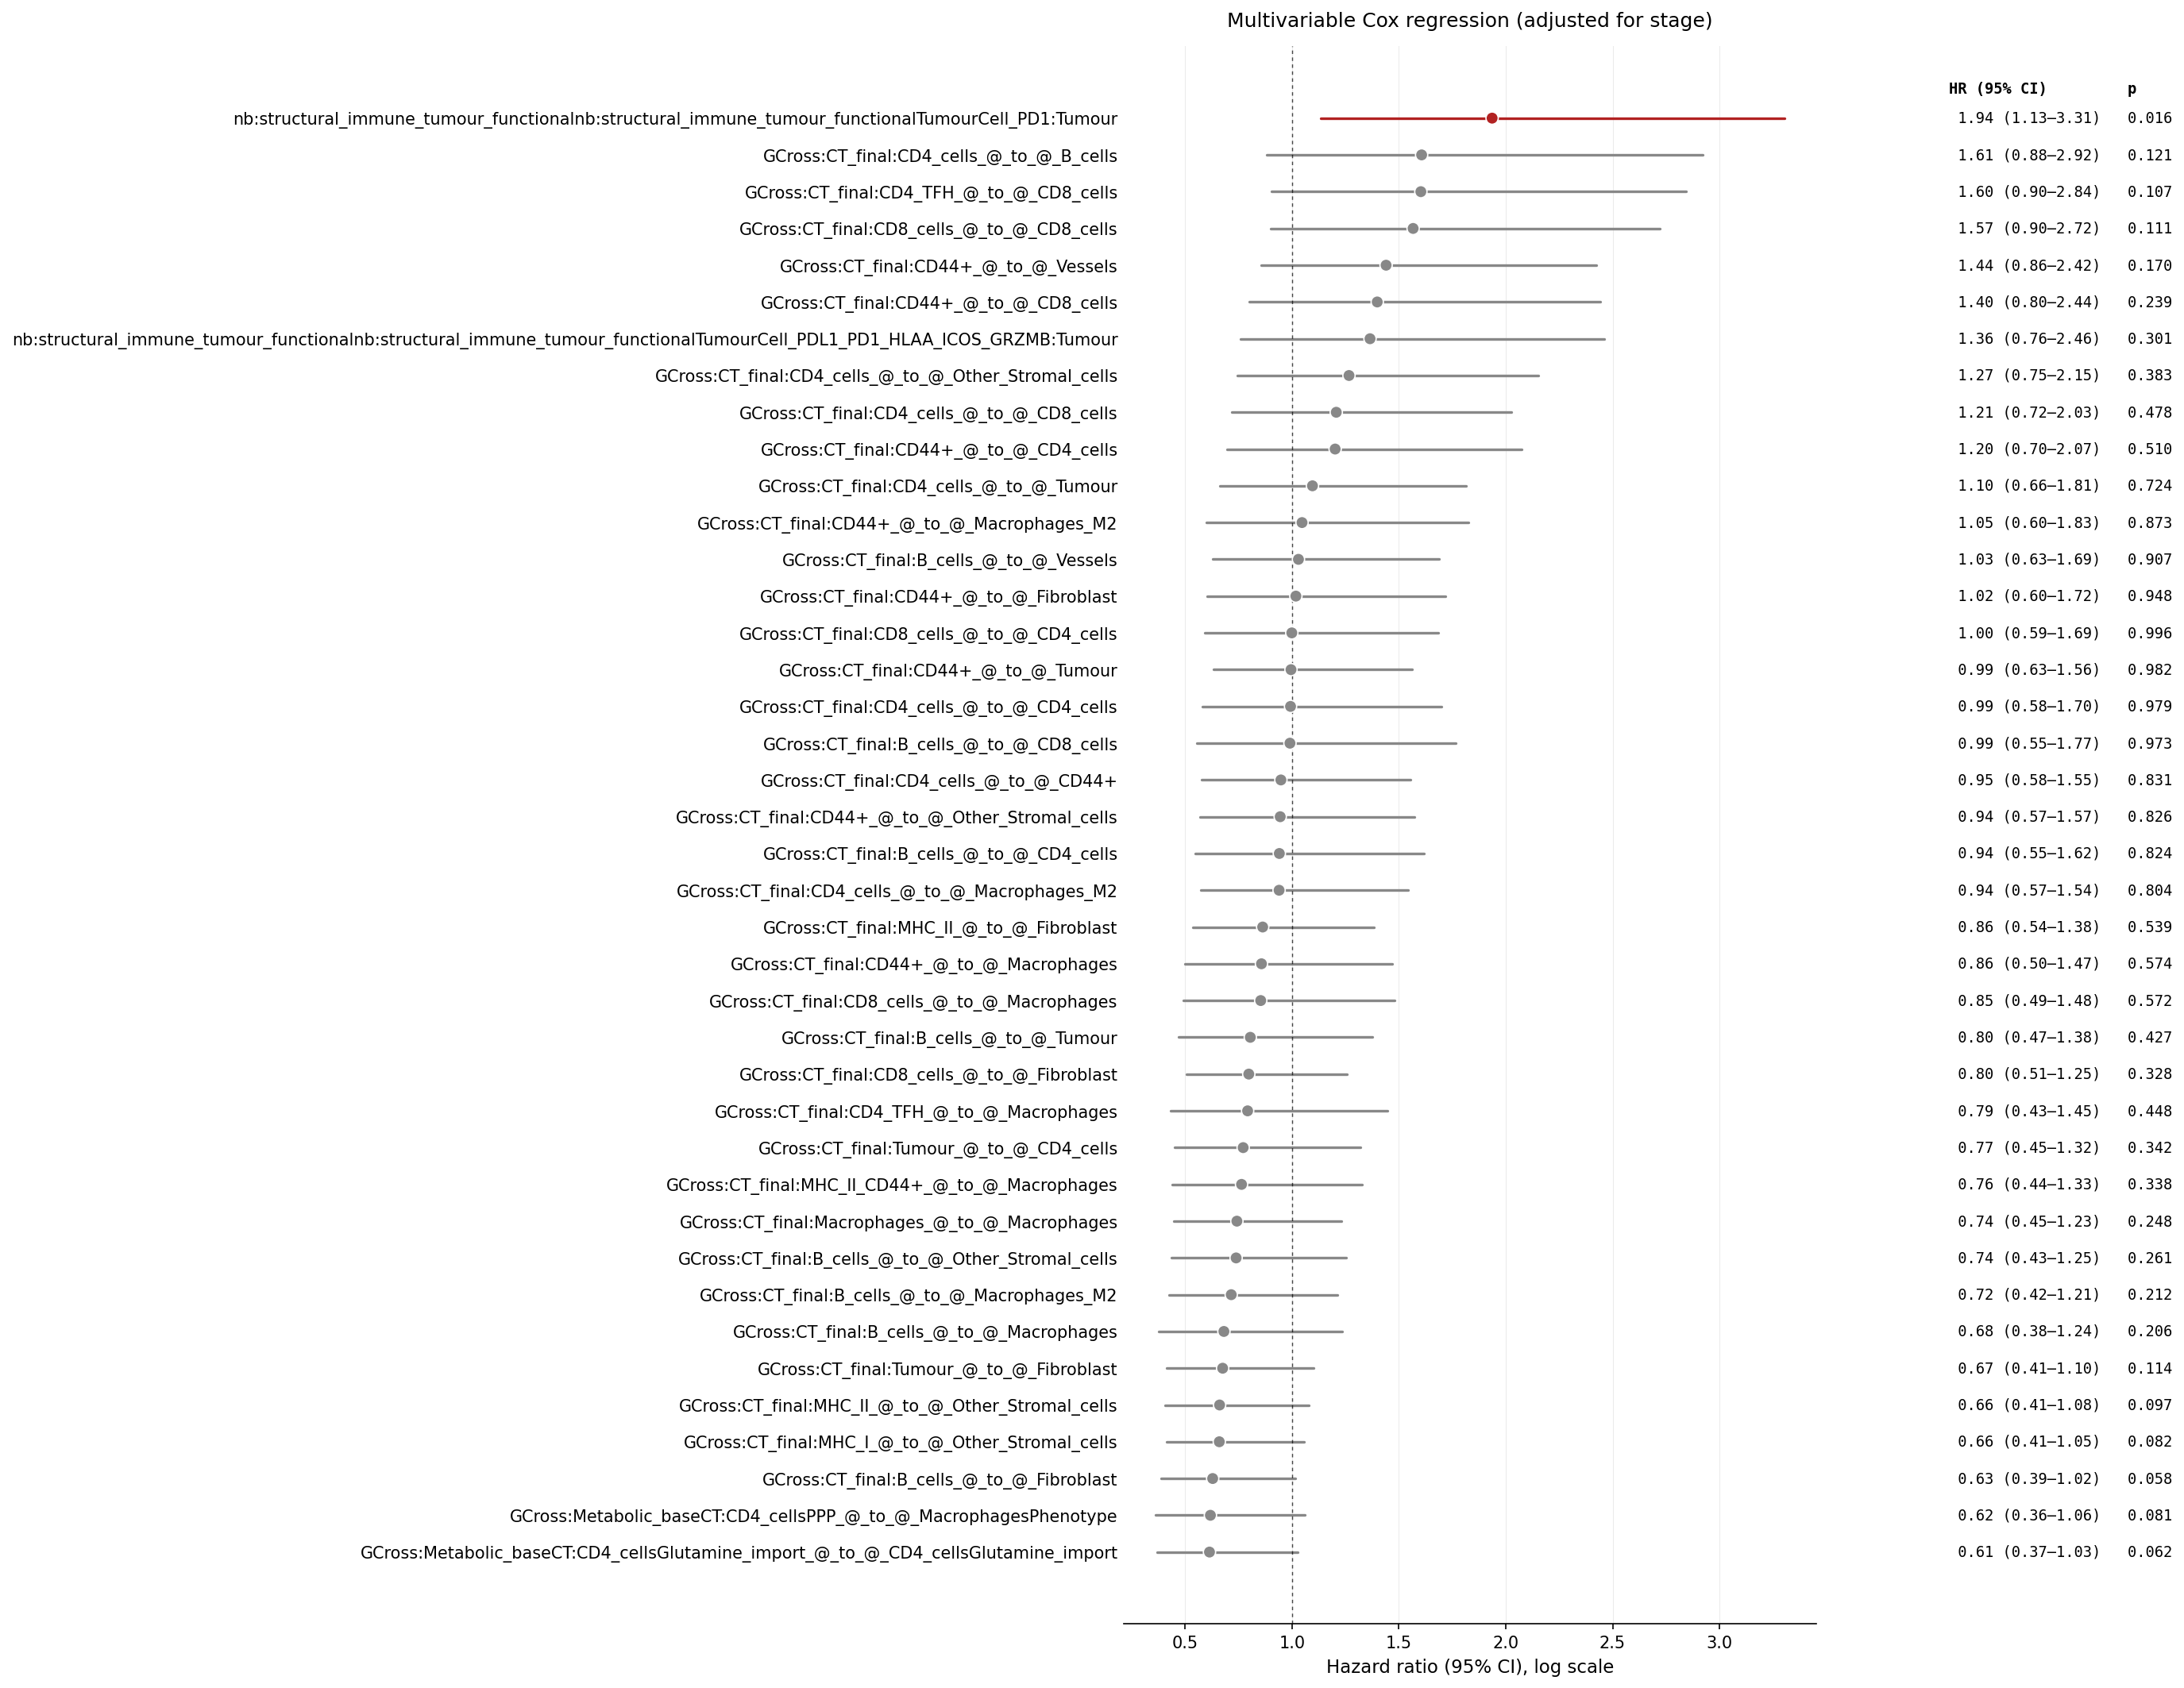

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def compute_cox_HRs(X_, Y_, features):

    results = []

    for feat in features:
        vals = X_[[feat]]
        clin = pd.concat([Y_[['Relapse_status', 'Relapse_followup', 'patientID']], stages3.to_frame('stage3'), stages3.to_frame('stage2'), sex.to_frame('sex')], axis=1).groupby(by='patientID').first()
        scaler = StandardScaler()
        imputer = SimpleImputer(strategy='median')
        vals = pd.DataFrame(imputer.fit_transform(vals), index=vals.index, columns=imputer.get_feature_names_out())
        vals = pd.DataFrame(scaler .fit_transform(vals), index=vals.index, columns=scaler .get_feature_names_out())
        vals = pd.concat([vals, Y_[['patientID']]], axis=1).groupby(by='patientID').mean()
        vals = pd.concat([vals, clin], axis=1)
        vals['Relapse_followup'] = vals['Relapse_followup'].astype(float)
        vals = vals.loc[:,vals.columns != 'patientID']

        print(vals)

        from lifelines import CoxPHFitter
        cph = CoxPHFitter(penalizer=1e-5)
        cph.fit(vals, duration_col='Relapse_followup', event_col='Relapse_status')
        results.append(cph.summary)

    return pd.concat(results, axis=0)

def plot_cox_forest(results_df, features=None,
                    title='Multivariable Cox regression (adjusted for stage)',
                    figsize=None, save_path=None):

    df = results_df.copy()
    print(df)
    if features is not None:
        df = df.loc[features]
        df = df.sort_values('coef')
    else:
        df = df.drop(index=[c for c in ('stage2', 'stage3') if c in df.index],
                     errors='ignore')
        df = df[~df.index.duplicated(keep='first')]
        df = df.sort_values('coef')

    n = len(df)
    if figsize is None:
        figsize = (7.5, max(2.5, 0.4 * n + 1.2))

    hr   = df['exp(coef)'].values
    lo   = df['exp(coef) lower 95%'].values
    hi   = df['exp(coef) upper 95%'].values
    pval = df['p'].values
    y    = np.arange(n)

    colors = ['#B22222' if (p < 0.05 and h > 1) else
              '#1F4E79' if (p < 0.05 and h < 1) else
              '#888888' for h, p in zip(hr, pval)]

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    for i, (l, h, c) in enumerate(zip(lo, hi, colors)):
        ax.plot([l, h], [i, i], color=c, lw=1.6, solid_capstyle='round', zorder=2)
    ax.scatter(hr, y, s=55, c=colors, edgecolor='white', lw=0.8, zorder=3)

    ax.axvline(1, color='black', ls=(0, (3, 3)), lw=0.7, alpha=0.7)
    #ax.set_xscale('log')
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=10)
    ax.set_xlabel('Hazard ratio (95% CI), log scale', fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)

    fig.canvas.draw()
    x_text = ax.get_xlim()[1] * 1.18
    ax.text(x_text, n - 0.4, 'HR (95% CI)         p',
            fontsize=9, family='monospace', fontweight='bold',
            va='bottom', clip_on=False)
    for i, (h, l, u, p) in enumerate(zip(hr, lo, hi, pval)):
        p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
        ax.text(x_text, i, f'{h:>5.2f} ({l:.2f}–{u:.2f})   {p_str}',
                fontsize=9, family='monospace', va='center', clip_on=False)

    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=0.25, lw=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
    return fig, ax

stages = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['stage_grouped']
stages2 = stages == 'stage2'
stages3 = stages == 'stage3'
sex = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['Sex']
sex = sex == 'M'
    
results = compute_cox_HRs(X_raw,
                          dfPatientAnnData_LUAD[['Relapse_status', 'Relapse_followup', 'patientID']],
                          top_features)
results.to_csv('cox_forest_LUAD.csv')

plot_cox_forest(results, features=top_features,
                save_path='cox_forest_LUAD.pdf')

In [485]:
results

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
GCross:CT_final:B_cells_@_to_@_CD4_cells,-0.061611,0.940249,0.276247,-0.603046,0.479824,0.547143,1.615790,0.0,-0.223028,0.823514,0.280135
stage3,1.118387,3.059915,0.439992,0.256020,1.980755,1.291778,7.248212,0.0,2.541838,0.011027,6.502798
sex,-0.215635,0.806030,0.450233,-1.098075,0.666806,0.333512,1.948005,0.0,-0.478941,0.631981,0.662047
GCross:CT_final:B_cells_@_to_@_Fibroblast,-0.464795,0.628264,0.245285,-0.945545,0.015956,0.388468,1.016084,0.0,-1.894915,0.058104,4.105226
stage3,1.325420,3.763766,0.447588,0.448165,2.202675,1.565436,9.049191,0.0,2.961253,0.003064,8.350415
...,...,...,...,...,...,...,...,...,...,...,...
stage3,0.968203,2.633209,0.448568,0.089025,1.847381,1.093108,6.343184,0.0,2.158430,0.030894,5.016509
sex,-0.206602,0.813343,0.443165,-1.075190,0.661985,0.341233,1.938637,0.0,-0.466197,0.641074,0.641436
GCross:CT_final:MHC_II_CD44+_@_to_@_Macrophages,-0.269946,0.763420,0.281845,-0.822353,0.282460,0.439397,1.326389,0.0,-0.957783,0.338172,1.564170


In [434]:
# Output for mixed-effects modelling in R
pd.concat([X_raw[top_features], dfPatientAnnData_LUAD[['Relapse_status', 'Relapse_followup', 'patientID']], stages2.to_frame('stage2'), stages3.to_frame('stage3'), sex.to_frame('sex')], axis=1).to_csv('modellingdeatures_LUAD.csv')

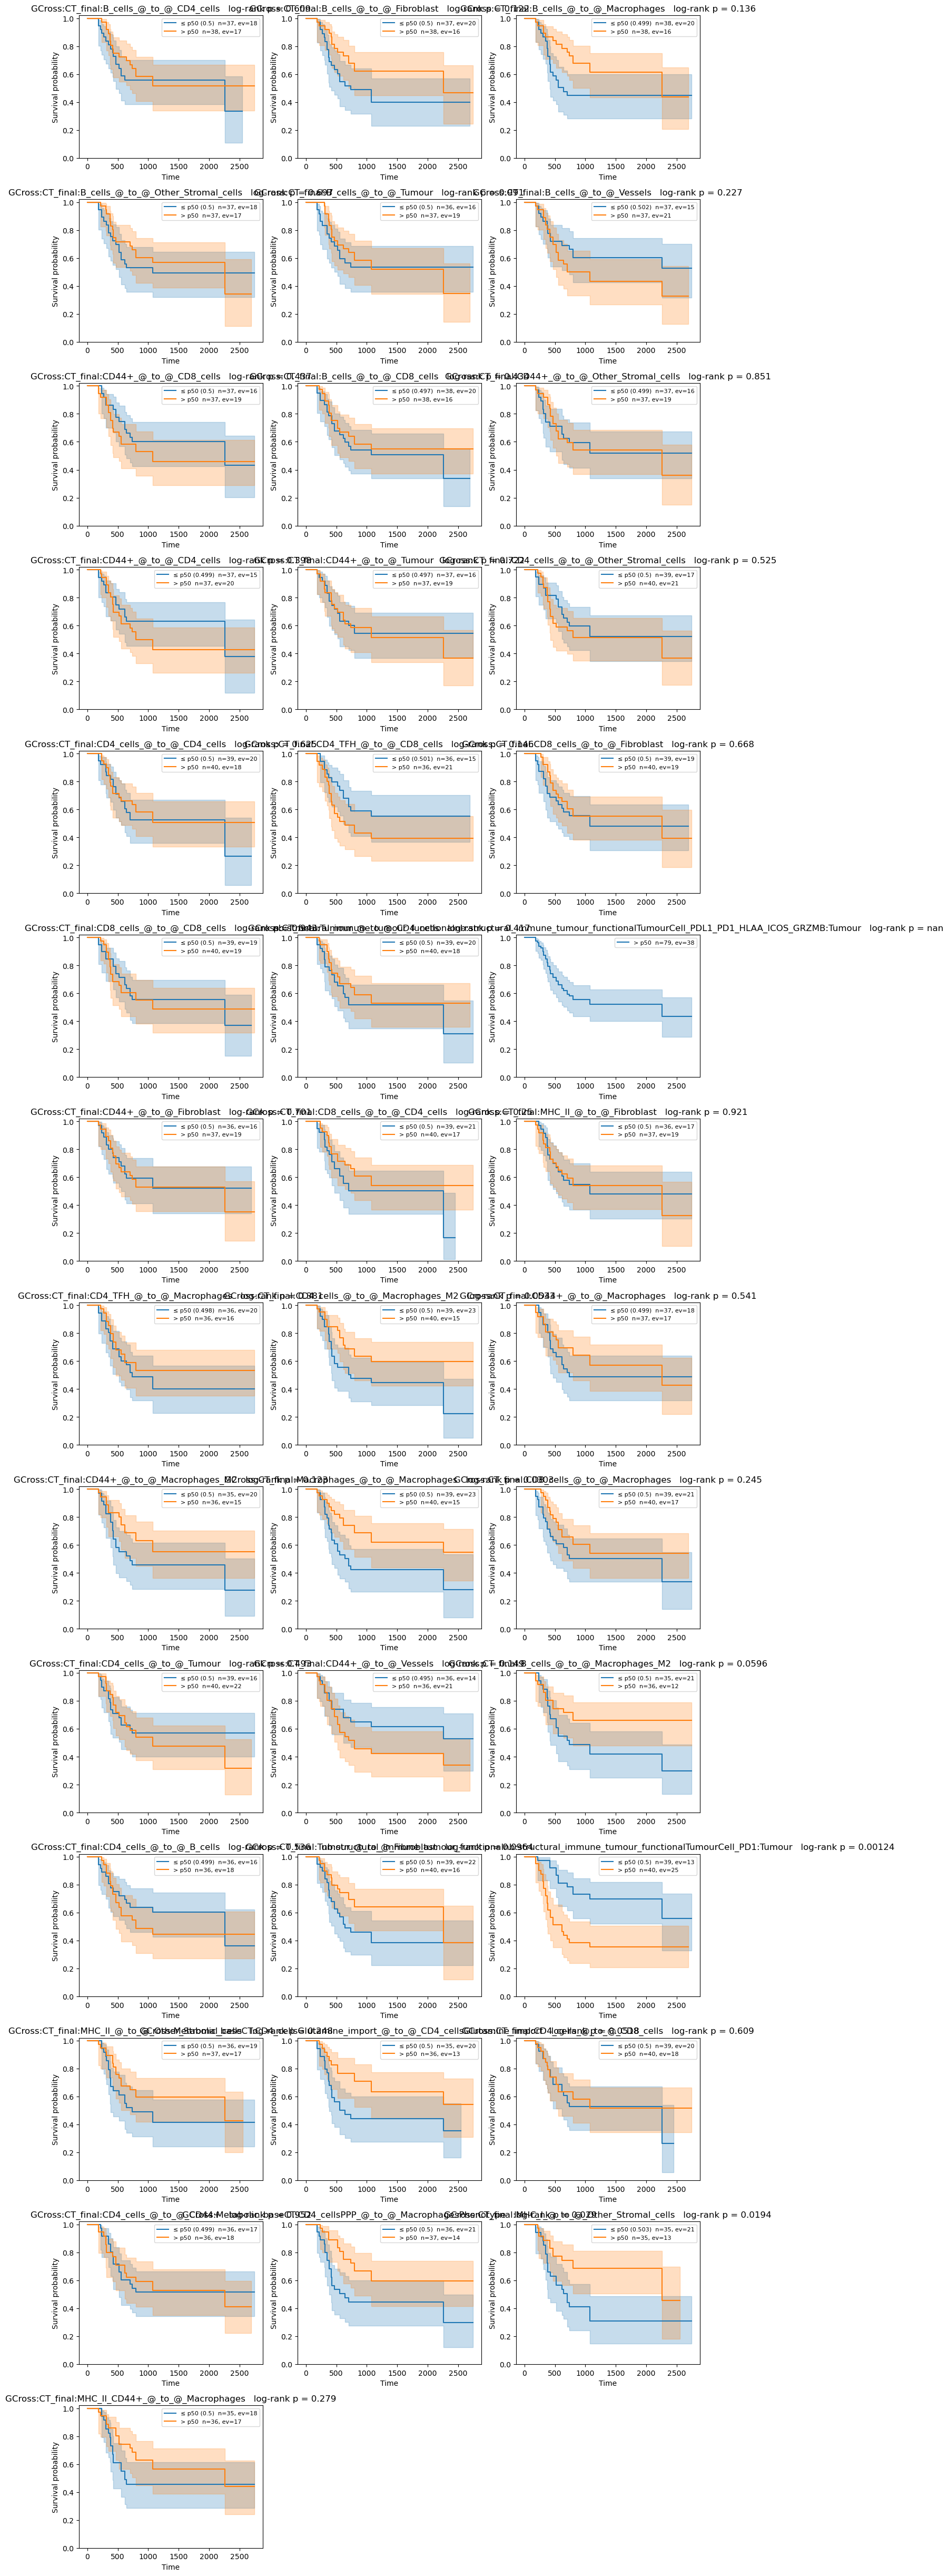

In [409]:
r, f = km_by_percentile(
    X_raw,
    Y,
    top_features,
    percentiles=50
    )

In [ ]:
top_features_sig = top_features

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(



CoxPH: 40 valid folds  |  RSF: 40 valid folds  |  GBSA: 40 valid folds


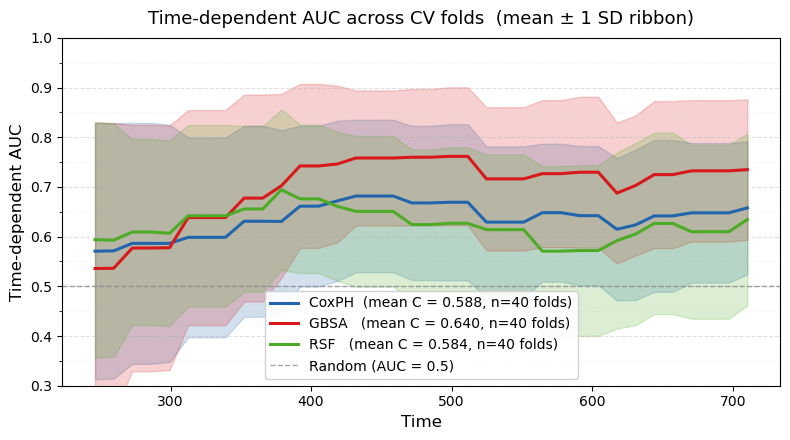

In [ ]:
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from numpy.linalg import LinAlgError
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=10, random_state=random_state
)


# ── Helpers (NaN-safe interp + coverage-masked aggregation) ───────────────────
def _safe_interp(eval_times, fold_times, auc):
    auc = np.asarray(auc, dtype=float)
    mask = np.isfinite(auc)
    if mask.sum() < 2:
        return np.full_like(eval_times, np.nan, dtype=float)
    return np.interp(eval_times, fold_times[mask], auc[mask],
                     left=np.nan, right=np.nan)


def _coverage_masked_summary(fold_aucs, min_frac=0.5):
    fold_aucs = np.asarray(fold_aucs, dtype=float)
    coverage  = np.isfinite(fold_aucs).sum(axis=0)
    threshold = max(2, int(np.ceil(min_frac * len(fold_aucs))))
    mean = np.nanmean(fold_aucs, axis=0)
    sd   = np.nanstd(fold_aucs,  axis=0)
    keep = coverage >= threshold
    mean = np.where(keep, mean, np.nan)
    sd   = np.where(keep, sd,   np.nan)
    return mean, sd


def _fold_time_window(Y_tr, Y_te, eval_times, right_edge_frac=0.9):
    """Per-fold time window using TRAINING-set support, capped at
    `right_edge_frac` of the smaller of (max train event time, max test event
    time) so IPCW weights stay bounded."""
    tr_event_t = Y_tr["time"][Y_tr["event"] == 1]
    te_event_t = Y_te["time"][Y_te["event"] == 1]
    if len(tr_event_t) == 0 or len(te_event_t) == 0:
        return np.array([], dtype=float)
    t_lo  = max(Y_tr["time"].min(), Y_te["time"].min())
    t_hi  = right_edge_frac * min(tr_event_t.max(), te_event_t.max())
    return eval_times[(eval_times > t_lo) & (eval_times < t_hi)]


t_min, t_max = np.percentile(Y["time"][Y["event"] == 1], [10, 90])
eval_times = np.linspace(t_min, t_max, 50)

cox_fold_aucs  = []
rsf_fold_aucs  = []
gbsa_fold_aucs = []
rsf_fold_c     = []
gbsa_fold_c    = []

for fold_i, (train_idx, test_idx) in enumerate(
        final_splitter.split(X_raw, Y, groups=patient_groups)):

    X_tr_raw = X_top[top_features_sig].iloc[train_idx, :]
    X_te_raw = X_top[top_features_sig].iloc[test_idx, :]
    Y_tr     = Y[train_idx]
    Y_te     = Y[test_idx]

    fold_times = _fold_time_window(Y_tr, Y_te, eval_times)

    if len(fold_times) < 5:
        print(f"Fold {fold_i}: skipped — fewer than 5 valid time points")
        continue

    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_tr_sc_im = scaler.fit_transform(imputer.fit_transform(X_tr_raw))
    X_te_sc_im = scaler.transform(imputer.transform(X_te_raw))

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_raw)
    X_te_sc = scaler.transform(X_te_raw)

    try:
        cox_model = CoxPHSurvivalAnalysis(ties="efron", alpha=0.1)
        cox_model.fit(X_tr_sc_im, Y_tr)
        cox_risk = cox_model.predict(X_te_sc_im)

        cox_auc, _ = cumulative_dynamic_auc(Y_tr, Y_te, cox_risk, fold_times)
        cox_fold_aucs.append(_safe_interp(eval_times, fold_times, cox_auc))

    except (LinAlgError, ValueError) as e:
        print(f"Fold {fold_i}: CoxPH skipped — {type(e).__name__}: {e}")

    try:
        imputer_rsf = StandardScaler()
        X_tr_rsf    = imputer_rsf.fit_transform(X_tr_raw)
        X_te_rsf    = imputer_rsf.transform(X_te_raw)

        rsf_model = RandomSurvivalForest(
            **{key: value for key, value in best_params.items()}
        )

        rsf_model.fit(X_tr_rsf, Y_tr)
        rsf_risk = rsf_model.predict(X_te_rsf)
        rsf_fold_c.append(rsf_model.score(X_te_rsf, Y_te))

        rsf_auc, _ = cumulative_dynamic_auc(Y_tr, Y_te, rsf_risk, fold_times)
        rsf_fold_aucs.append(_safe_interp(eval_times, fold_times, rsf_auc))

    except (ValueError,) as e:
        print(f"Fold {fold_i}: RSF skipped — {type(e).__name__}: {e}")

    try:
        gbsa_model = sksurv.ensemble.ComponentwiseGradientBoostingSurvivalAnalysis(
            **{'learning_rate': 1.0, 'n_estimators': 500, 'subsample': 1.0},
            random_state=random_state,
        )
        gbsa_model.fit(X_tr_sc_im, Y_tr)
        gbsa_risk = gbsa_model.predict(X_te_sc_im)
        gbsa_fold_c.append(gbsa_model.score(X_te_sc_im, Y_te))

        gbsa_auc, _ = cumulative_dynamic_auc(Y_tr, Y_te, gbsa_risk, fold_times)
        gbsa_fold_aucs.append(_safe_interp(eval_times, fold_times, gbsa_auc))

    except (ValueError,) as e:
        print(f"Fold {fold_i}: GBSA skipped — {type(e).__name__}: {e}")

print(f"\nCoxPH: {len(cox_fold_aucs)} valid folds  |  "
      f"RSF: {len(rsf_fold_aucs)} valid folds  |  "
      f"GBSA: {len(gbsa_fold_aucs)} valid folds")

if not cox_fold_aucs and not rsf_fold_aucs and not gbsa_fold_aucs:
    raise RuntimeError("No valid folds — check your data / splitter settings.")

cox_fold_aucs  = np.array(cox_fold_aucs)
rsf_fold_aucs  = np.array(rsf_fold_aucs)
gbsa_fold_aucs = np.array(gbsa_fold_aucs)

cox_mean,  cox_sd  = _coverage_masked_summary(cox_fold_aucs)
rsf_mean,  rsf_sd  = _coverage_masked_summary(rsf_fold_aucs)
gbsa_mean, gbsa_sd = _coverage_masked_summary(gbsa_fold_aucs)

fig, ax = plt.subplots(figsize=(8, 4.5))

COX_COLOR  = "#2166ac"
RSF_COLOR  = "#4dac26"
GBSA_COLOR = "#d7191c"


ax.fill_between(eval_times, cox_mean - cox_sd, cox_mean + cox_sd,
                color=COX_COLOR, alpha=0.20)
ax.fill_between(eval_times, gbsa_mean - gbsa_sd, gbsa_mean + gbsa_sd,
                color=GBSA_COLOR, alpha=0.20)
ax.fill_between(eval_times, rsf_mean - rsf_sd, rsf_mean + rsf_sd,
                color=RSF_COLOR, alpha=0.20)

ax.plot(eval_times, cox_mean, color=COX_COLOR, lw=2.2,
        label=f"CoxPH  (mean C = {np.nanmean(standard_fold_c):.3f},"
              f" n={len(cox_fold_aucs)} folds)")
ax.plot(eval_times, gbsa_mean, color=GBSA_COLOR, lw=2.2,
        label=f"GBSA   (mean C = {np.nanmean(gbsa_fold_c):.3f},"
              f" n={len(gbsa_fold_aucs)} folds)")
ax.plot(eval_times, rsf_mean, color=RSF_COLOR, lw=2.2,
        label=f"RSF   (mean C = {np.nanmean(rsf_fold_c):.3f},"
              f" n={len(rsf_fold_aucs)} folds)")

ax.axhline(0.5, color="grey", lw=1, ls="--", alpha=0.7, label="Random (AUC = 0.5)")

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Time-dependent AUC", fontsize=12)
ax.set_title("Time-dependent AUC across CV folds  (mean ± 1 SD ribbon)",
             fontsize=13, pad=10)
ax.set_ylim(0.3, 1.0)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.grid(axis="y", which="major", ls="--", alpha=0.4)
ax.grid(axis="y", which="minor", ls=":",  alpha=0.2)
ax.legend(framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig("Figure6c.pdf", dpi=200, bbox_inches="tight")
plt.show()
